## Calculating the deviations due to a binary lens at a specific coordinate origin
#### To minimize deviations at low magnfications, try:
$\xi \rightarrow \xi + \dfrac{q}{(1+q)(s+s^{-1})}$

#### Importing libraries

In [34]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

init_time = t.time()
from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF
print(f'Custom library import time: {(t.time() - init_time):.3} seconds')

import VBMicrolensing
import numexpr

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Custom library import time: 0.000246 seconds


#### Defining and initializing VBMicrolensing

In [35]:
VBM = VBMicrolensing.VBMicrolensing()

# Set relative accuracy
VBM.RelTol = 1e-03

# Set accuracy
VBM.Tol=1e-03

#### Importing all simulations and checking parameters

In [36]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

# All triple lens
betas = [0, 45, 90, 135, 180]
pmrs = [0.1, 0.03, 0.01, 0.003, 0.001]
offsets = ['', '_binary_offset', '_cm']
triple_lenses = []
triple_lenses_binary_offset = []
triple_lenses_cm_offset = []

for pmr in pmrs:
    constant_pmr = []
    constant_pmr_binary_offset = []
    constant_pmr_cm_offset = []

    for beta in betas:
        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}_triple_offset.pkl'
        constant_pmr.append(IRSC.caustic_reader(file_path))

        print(file_path)

        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}_binary_offset.pkl'
        constant_pmr_binary_offset.append(IRSC.caustic_reader(file_path))

        file_path = f'../Unity/Simulations/Collection_0.8/triple_1e11_{beta}_{pmr*1e-3:.0e}_cm.pkl'
        constant_pmr_cm_offset.append(IRSC.caustic_reader(file_path))

    triple_lenses.append(constant_pmr)
    triple_lenses_binary_offset.append(constant_pmr_binary_offset)
    triple_lenses_cm_offset.append(constant_pmr_cm_offset)

triple_lenses = np.array(triple_lenses)
triple_lenses_binary_offset = np.array(triple_lenses_binary_offset)
triple_lenses_cm_offset = np.array(triple_lenses_cm_offset)

../Unity/Simulations/Collection_0.8/triple_1e11_0_1e-04_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_45_1e-04_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_90_1e-04_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_135_1e-04_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_180_1e-04_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_0_3e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_45_3e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_90_3e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_135_3e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_180_3e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_0_1e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_45_1e-05_triple_offset.pkl
../Unity/Simulations/Collection_0.8/triple_1e11_90_1e-05_triple_offset.pkl
../Unity/Simulations/Col

In [37]:
triple_offsets = []
binary_offsets = []
cm_offsets = []

for i, pmr in enumerate(pmrs):
    constant_pmr_triple_offsets = []
    constant_pmr_binary_offsets = []
    constant_pmr_cm_offsets = []

    for j, beta in enumerate(betas):
        args = {
            'sep2': '0.8',
            'angle2': f'{beta}',
            'planet_mass_ratio': f'{pmr}',
            'origin': 'triple_offset'  # Options: 'triple_offset', 'binary_offset', 'cm'
        }

        ''' Preparing lens parameters '''
        # Big planet parameters
        s1 = 0.8
        alpha1 = 0
        q1 = 1e-3

        # Small planet parameters
        s2 = np.float64(numexpr.evaluate(args['sep2']).item())
        alpha2 = np.float64(args['angle2'])
        q2 = np.float64(args['planet_mass_ratio']) * q1

        # Defining single lens attributes
        single_lens_attributes = np.array([
            [0, 0, 1]
        ])

        # Defining binary lens attributes
        binary_lens_attributes = np.array([
            [0, 0, 1],
            [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
        ])

        # Triple lens attributes
        triple_lens_attributes = np.array([
            [0, 0, 1],
            [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
            [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
        ])

        # Rotation matrix for first planet
        first_planet_DCM = np.array([
            [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
            [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
        ])

        # Rotation matrix for second planet
        second_planet_DCM = np.array([
            [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
            [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
        ])

        # Calculating translation of coordinate origin for each planet
        q1 = triple_lens_attributes[1, 2]
        q2 = triple_lens_attributes[2, 2]

        delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
        delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

        delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
        delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

        total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)

        CM_sum = 0
        for k in range(3):
            CM_sum += triple_lens_attributes[k, :2] * triple_lens_attributes[k, 2]

        total_M = np.sum(triple_lens_attributes[:, 2])
        lens_CM = CM_sum / total_M

        lens_attributes_triple_offset = triple_lens_attributes.copy()
        lens_attributes_triple_offset[:, :2] -= total_offset

        lens_attributes_binary_offset = triple_lens_attributes.copy()
        lens_attributes_binary_offset[:, :2] -= delta1

        lens_attributes_cm_offset = triple_lens_attributes.copy()
        lens_attributes_cm_offset[:, :2] -= lens_CM

        # Checking if the lens attributes are valid
        print((np.abs(triple_lenses[i, j].lens_att - lens_attributes_triple_offset) < 1e-15).all())
        print((np.abs(triple_lenses_binary_offset[i, j].lens_att - lens_attributes_binary_offset) < 1e-15).all())
        print((np.abs(triple_lenses_cm_offset[i, j].lens_att - lens_attributes_cm_offset) < 1e-15).all())
        
        constant_pmr_triple_offsets.append(total_offset)
        constant_pmr_binary_offsets.append(delta1)
        constant_pmr_cm_offsets.append(lens_CM)

    triple_offsets.append(constant_pmr_triple_offsets)
    binary_offsets.append(constant_pmr_binary_offsets)
    cm_offsets.append(constant_pmr_cm_offsets)

triple_offsets = np.array(triple_offsets)
binary_offsets = np.array(binary_offsets)
cm_offsets = np.array(cm_offsets)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [38]:
print(binary_offsets)

[[[0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]]

 [[0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]]

 [[0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]]

 [[0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]]

 [[0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]
  [0.00048732 0.        ]]]


#### Checking parameters

In [39]:
args = {
    'sep2': '1/0.9',
    'angle2': '45',
    'planet_mass_ratio': '0.01',
    'origin': 'triple_offset'  # Options: 'triple_offset', 'binary_offset', 'cm'

}

''' Preparing lens parameters '''
# Big planet parameters
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Small planet parameters
s2 = np.float64(numexpr.evaluate(args['sep2']).item())
alpha2 = np.float64(args['angle2'])
q2 = np.float64(args['planet_mass_ratio']) * q1

print(f'q1 = {q1}')
print(f'q2 = {q2}')
print(f's1 = {s1}')
print(f's2 = {s2}')
print(f'alpha1 = {alpha1}')
print(f'alpha2 = {alpha2}')

# Defining single lens attributes
single_lens_attributes = np.array([
    [0, 0, 1]
])

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Triple lens attributes
triple_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Rotation matrix for second planet
second_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
    [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
])

# Calculating translation of coordinate origin for each planet
q1 = triple_lens_attributes[1, 2]
q2 = triple_lens_attributes[2, 2]

delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)
print(f'Total offset: {total_offset}')
print(f'Binary offset: {delta1}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Correcting triple lens attributes
if args['origin'] == 'triple_offset':
    triple_lens_attributes[:, :2] -= total_offset
elif args['origin'] == 'binary_offset':
    triple_lens_attributes[:, :2] -= delta1
elif args['origin'] == 'cm':
    CM_sum = 0

    for i in range(3):
        CM_sum += triple_lens_attributes[i, :2] * triple_lens_attributes[i, 2]

    total_M = np.sum(triple_lens_attributes[:, 2])

    lens_CM = CM_sum / total_M

    triple_lens_attributes[:, :2] -= lens_CM

else:
    raise ValueError(f'Wrong origin passed in. Got {args["origin"]}.')

# Map parameters
pixels = 2000
delta = 0.01

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(triple_lens_attributes)
num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

print(f'Angular width: {ang_width}')
print(f'Thickness: {thickness}')
print(f'Annulus lower bound: {y_minus}')
print(f'Annulus upper bound: {y_plus}')
print(f'Number of rays in theta: {num_theta}')
print(f'Number of rays in r: {num_r}')

q1 = 0.001
q2 = 1e-05
s1 = 0.8
s2 = 1.1111111111111112
alpha1 = 0
alpha2 = 45.0
Total offset: [4.82527446e-04 3.48115387e-08]
Binary offset: [0.00048732 0.        ]
Angular width: 0.07680319680319682
Thickness: 0.059738867403980045
Annulus lower bound: -0.970576558378381
Annulus upper bound: 1.030315425782361
Number of rays in theta: 194884
Number of rays in r: 779536


In [40]:
print(f'Angular width of single lens: {single_lens.ang_width}')
print(f'Angular width of binary lens: {binary_lens.ang_width}')

ang_width = single_lens.ang_width
pixels = single_lens.pixels

# for triple_lens in triple_lenses:
#     print(triple_lens.lens_att)

print(triple_lenses[0, 1].lens_att)
print(triple_lenses_binary_offset[0, 1].lens_att)

Angular width of single lens: 0.07680319680319682
Angular width of binary lens: 0.07680319680319682
[[-4.46151379e-04 -3.13541498e-06  1.00000000e+00]
 [ 7.99553849e-01 -3.13541498e-06  1.00000000e-03]
 [ 5.65239274e-01  5.65682290e-01  1.00000000e-04]]
[[-4.87317560e-04  0.00000000e+00  1.00000000e+00]
 [ 7.99512682e-01  0.00000000e+00  1.00000000e-03]
 [ 5.65198107e-01  5.65685425e-01  1.00000000e-04]]


#### Plotting all simulations

Plotting magnification map: 0.219 seconds
Plotting magnification map: 0.119 seconds


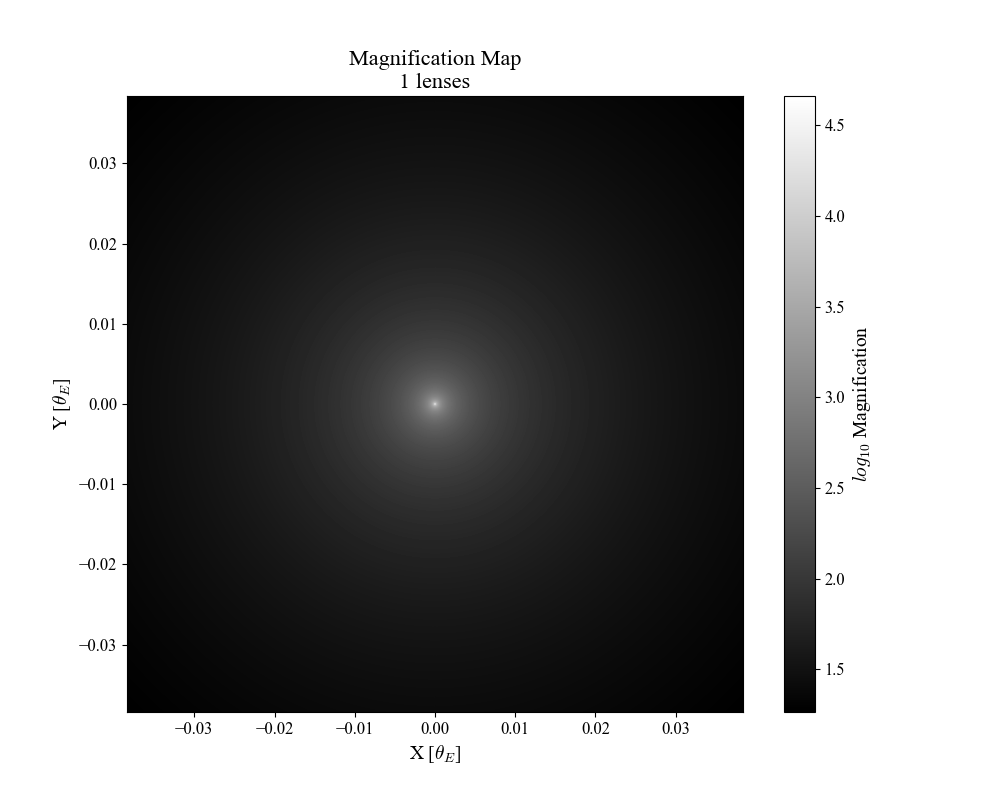

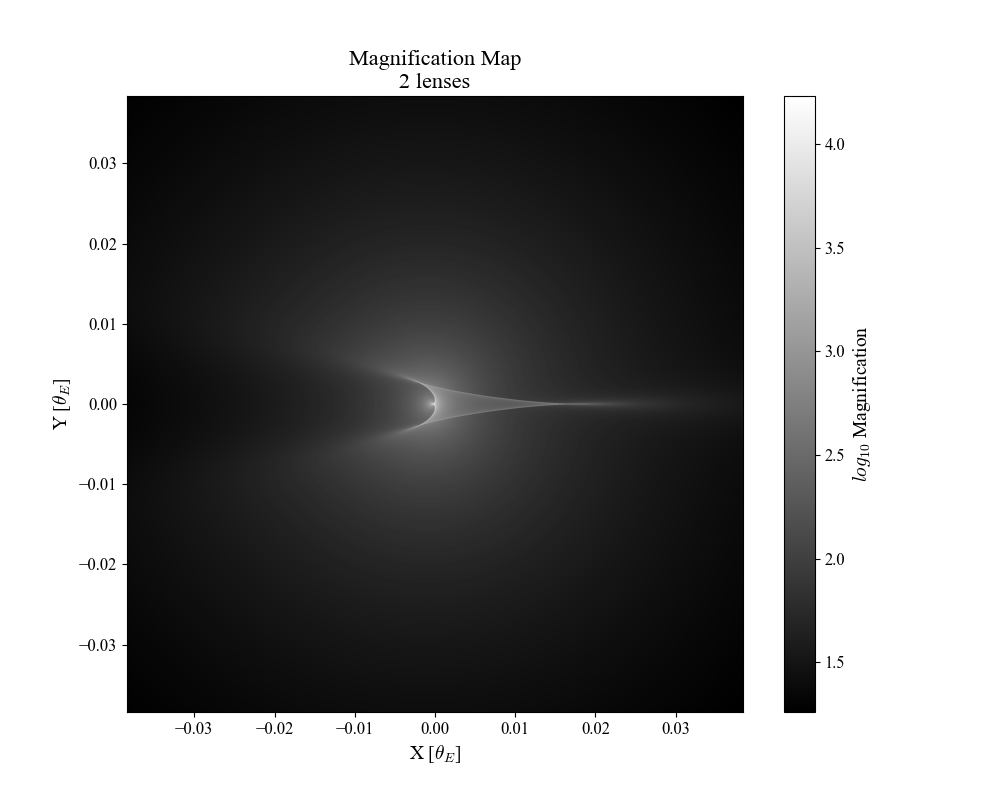

In [41]:
# Single lens
single_lens.plot()

# Binary lens
binary_lens.plot()

#### Calculating VBMicrolensing caustic

In [42]:
all_caustic_points = []
all_caustic_points_binary_offset = []
all_caustic_points_cm_offset = []

binary_all_caustic_points_triple_offset = []
binary_all_caustic_points_binary_offset = []

binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1]
])

parameters = [item for sublist in binary_lens_attributes for idx, item in enumerate(sublist)]
VBM.SetLensGeometry(parameters)
binary_caustic_points_inertial = VBM.Multicaustics()

print('Binary lens attributes:', binary_lens_attributes)

for row in triple_lenses:
    constant_pmr = []
    for triple_lens in row:
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)
    
    all_caustic_points.append(constant_pmr)

for i, row in enumerate(triple_lenses_binary_offset):
    constant_pmr = []
    binary_constant_pmr_binary_offset = []
    binary_constant_pmr_triple_offset = []

    for j, triple_lens in enumerate(row):
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)

        binary_lens_attributes_binary_offset = binary_lens_attributes.copy()
        binary_lens_attributes_binary_offset[:, :2] -= binary_offsets[i, j]

        parameters = [item for sublist in binary_lens_attributes_binary_offset for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        binary_caustic_points_binary_offset = VBM.Multicaustics()
        binary_constant_pmr_binary_offset.append(binary_caustic_points_binary_offset)

        binary_lens_attributes_triple_offset = binary_lens_attributes.copy()
        binary_lens_attributes_triple_offset[:, :2] += triple_offsets[i, j] - 2*binary_offsets[i, j]

        parameters = [item for sublist in binary_lens_attributes_triple_offset for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        binary_caustic_points_triple_offset = VBM.Multicaustics()
        binary_constant_pmr_triple_offset.append(binary_caustic_points_triple_offset)

    all_caustic_points_binary_offset.append(constant_pmr)
    binary_all_caustic_points_binary_offset.append(binary_constant_pmr_binary_offset)
    binary_all_caustic_points_triple_offset.append(binary_constant_pmr_triple_offset)

for row in triple_lenses_cm_offset:
    constant_pmr = []
    for triple_lens in row:
        parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
        VBM.SetLensGeometry(parameters)

        caustic_points = VBM.Multicaustics()
        constant_pmr.append(caustic_points)
    
    all_caustic_points_cm_offset.append(constant_pmr)

Binary lens attributes: [[0.    0.    1.   ]
 [0.8   0.    0.001]]


#### Defining source parameters

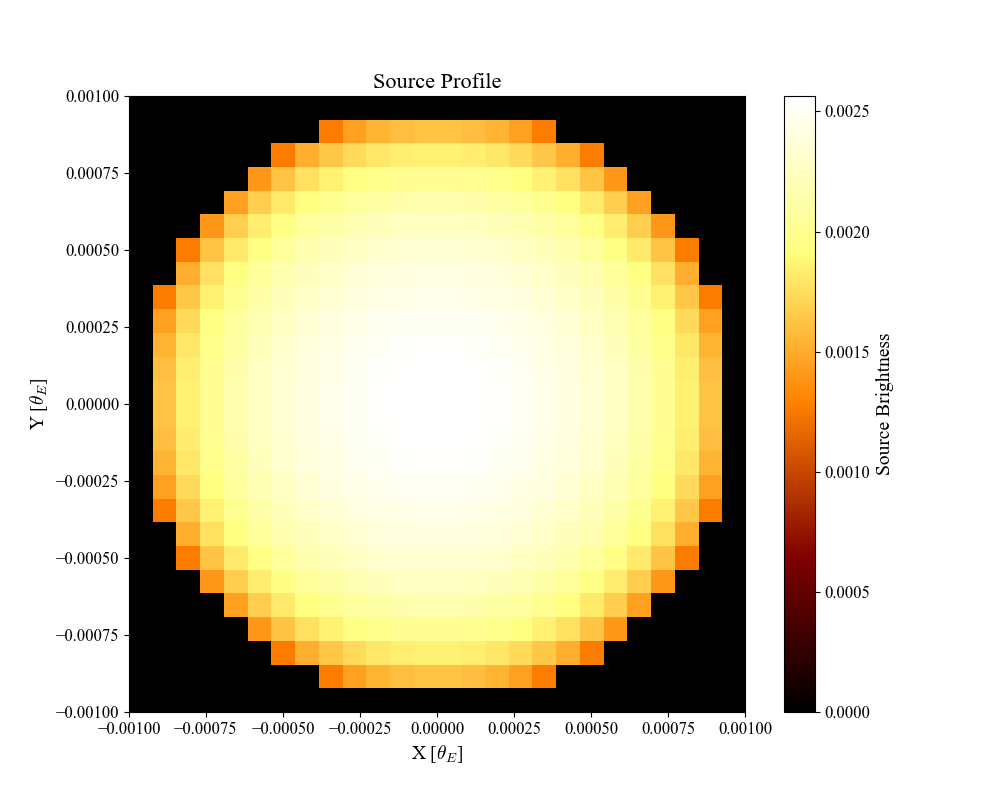

In [43]:
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='LD', LD=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius, radius, -radius, radius])
plt.colorbar(img, ax=ax, label='Source Brightness')

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

In [44]:
print(source_profile.shape)
print(np.sum(source_profile))

(26, 26)
1.0


#### Convolving all lens configurations

In [45]:
# Single lens
convolved_single_lens = single_lens.convolve(source_profile=source_profile)

# Binary lens
convolved_binary_lens = binary_lens.convolve(source_profile=source_profile)

# All triple lenses
convolved_triple_lenses = []
convolved_triple_lenses_cm_offset = []
convolved_triple_lenses_binary_offset = []

for row in triple_lenses:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses.append(constant_pmr)

for row in triple_lenses_binary_offset:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses_binary_offset.append(constant_pmr)

for row in triple_lenses_cm_offset:
    constant_pmr = []
    for triple_lens in row:
        convolved_triple_lens = triple_lens.convolve(source_profile=source_profile)
        constant_pmr.append(convolved_triple_lens)
    
    convolved_triple_lenses_cm_offset.append(constant_pmr)

convolved_triple_lenses = np.array(convolved_triple_lenses)
convolved_triple_lenses_binary_offset = np.array(convolved_triple_lenses_binary_offset)
convolved_triple_lenses_cm_offset = np.array(convolved_triple_lenses_cm_offset)

Convolving source profile with magnification map: 0.222 seconds
Convolving source profile with magnification map: 0.186 seconds
Convolving source profile with magnification map: 0.253 seconds
Convolving source profile with magnification map: 0.185 seconds
Convolving source profile with magnification map: 0.112 seconds
Convolving source profile with magnification map: 0.108 seconds
Convolving source profile with magnification map: 0.108 seconds
Convolving source profile with magnification map: 0.108 seconds
Convolving source profile with magnification map: 0.118 seconds
Convolving source profile with magnification map: 0.118 seconds
Convolving source profile with magnification map: 0.178 seconds
Convolving source profile with magnification map: 0.111 seconds
Convolving source profile with magnification map: 0.112 seconds
Convolving source profile with magnification map: 0.109 seconds
Convolving source profile with magnification map: 0.113 seconds
Convolving source profile with magnifica

#### Calculating fractional deviations from single and binary for all triple lens configurations

In [46]:
# Single lens deviations
fractional_deviation_single = []
fractional_deviation_single_binary_offset = []
fractional_deviation_single_cm_offset = []

# Binary lens deviations
fractional_deviation_binary = []
fractional_deviation_binary_binary_offset = []
fractional_deviation_binary_cm_offset = []

for row in convolved_triple_lenses:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single.append(constant_pmr_single)
    fractional_deviation_binary.append(constant_pmr_binary)

for row in convolved_triple_lenses_binary_offset:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single_binary_offset.append(constant_pmr_single)
    fractional_deviation_binary_binary_offset.append(constant_pmr_binary)

for row in convolved_triple_lenses_cm_offset:
    constant_pmr_single = []
    constant_pmr_binary = []

    for convolved_triple_lens in row:
        constant_pmr_single.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
        constant_pmr_binary.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

    fractional_deviation_single_cm_offset.append(constant_pmr_single)
    fractional_deviation_binary_cm_offset.append(constant_pmr_binary)

fractional_deviation_single = np.array(fractional_deviation_single)
fractional_deviation_single_binary_offset = np.array(fractional_deviation_single_binary_offset)
fractional_deviation_single_cm_offset = np.array(fractional_deviation_single_cm_offset)

fractional_deviation_binary = np.array(fractional_deviation_binary)
fractional_deviation_binary_binary_offset = np.array(fractional_deviation_binary_binary_offset)
fractional_deviation_binary_cm_offset = np.array(fractional_deviation_binary_cm_offset)

In [47]:
print(fractional_deviation_single.shape)
print(fractional_deviation_single_binary_offset.shape)
print(fractional_deviation_single_cm_offset.shape)

print(fractional_deviation_binary.shape)
print(fractional_deviation_binary_binary_offset.shape)
print(fractional_deviation_binary_cm_offset.shape)

(5, 5, 2000, 2000)
(5, 5, 2000, 2000)
(5, 5, 2000, 2000)
(5, 5, 2000, 2000)
(5, 5, 2000, 2000)
(5, 5, 2000, 2000)


#### Plotting all fractional deviations

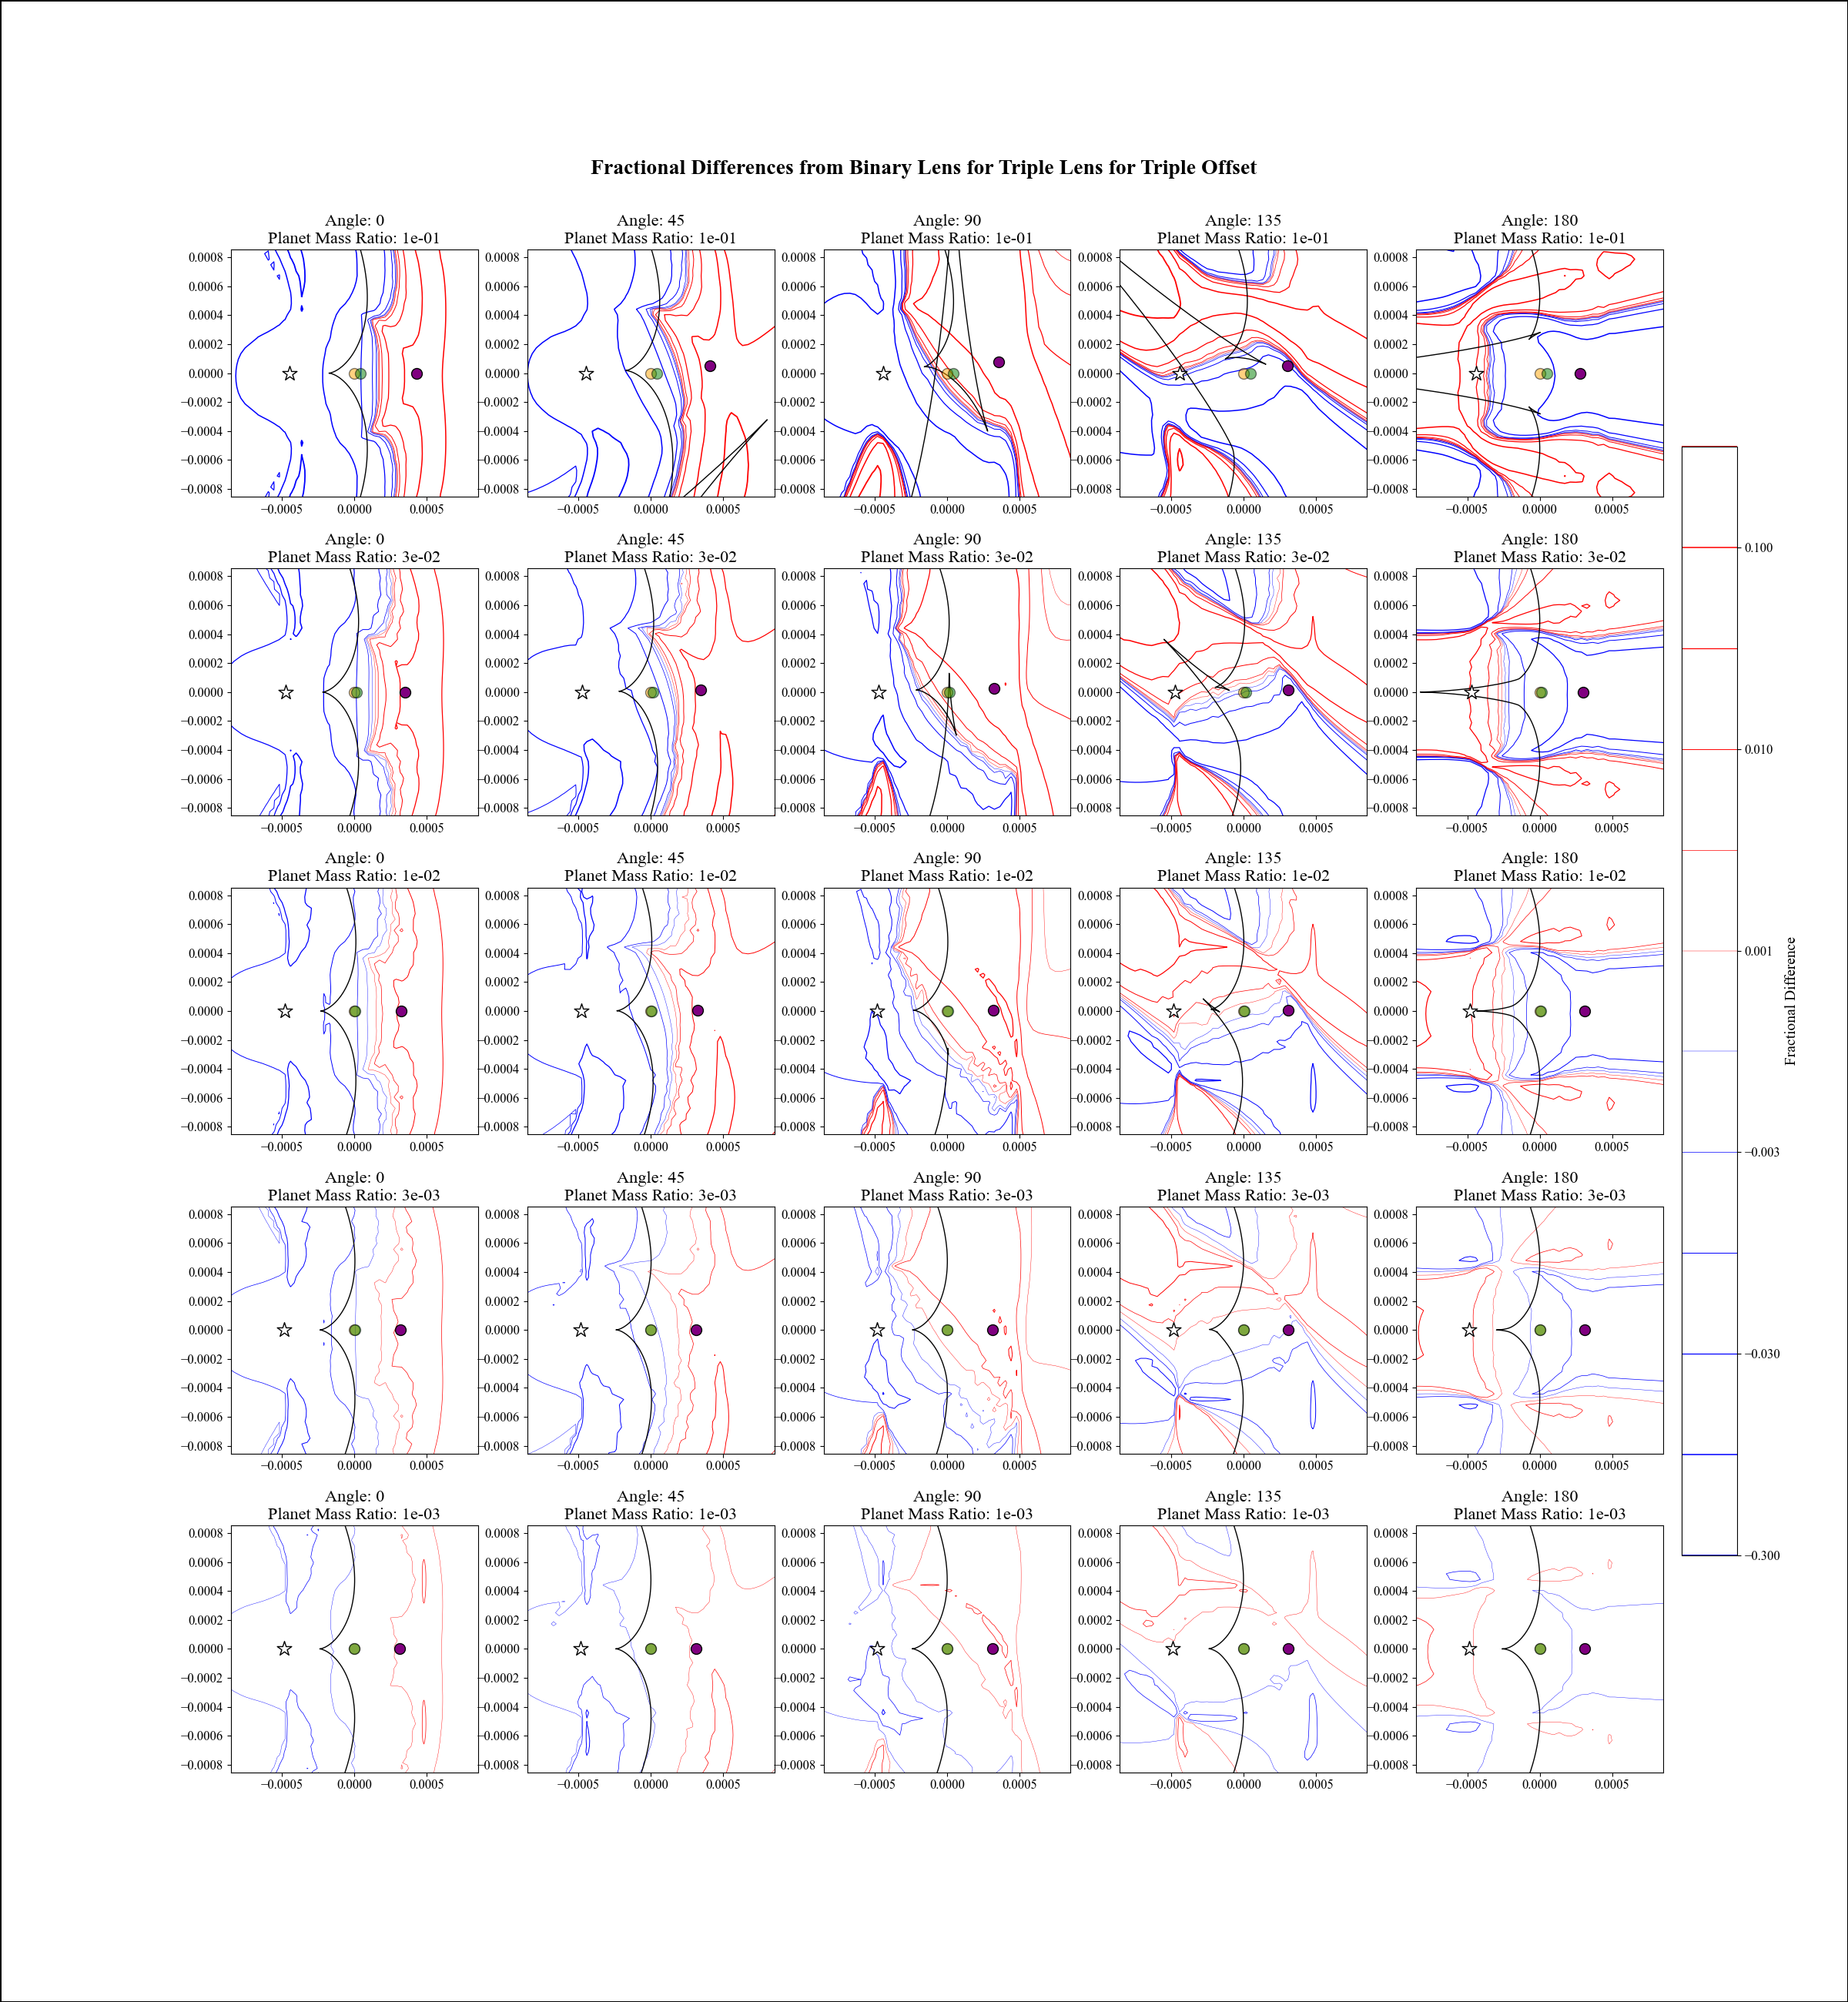

In [48]:
fig = plt.figure(figsize=(24, 26), edgecolor='black', linewidth=2, dpi=100)
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for Triple Offset', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        # ax.set_xlim(-ang_width/2, ang_width/2)
        # ax.set_ylim(-ang_width/2, ang_width/2)

        ax.scatter(single_lens.lens_att[:, 0] - triple_offsets[i, j, 0], single_lens.lens_att[:, 1] - triple_offsets[i, j, 1], edgecolor='black', facecolor='white', marker='*', s=200, zorder=20)
        ax.scatter(triple_offsets[i, j, 0] - triple_offsets[i, j, 0], triple_offsets[i, j, 1] - triple_offsets[i, j, 1], edgecolor='black', facecolor='orange', marker='o', s=100, zorder=20, alpha=0.5)
        ax.scatter(binary_offsets[i, j, 0] - triple_offsets[i, j, 0], binary_offsets[i, j, 1] - triple_offsets[i, j, 1], edgecolor='black', facecolor='green', marker='o', s=100, zorder=20, alpha=0.5)
        ax.scatter(cm_offsets[i, j, 0] - triple_offsets[i, j, 0], cm_offsets[i, j, 1] - triple_offsets[i, j, 1], edgecolor='black', facecolor='purple', marker='o', s=100, zorder=20)

        ax.set_xlim(-ang_width/90, ang_width/90)
        ax.set_ylim(-ang_width/90, ang_width/90)

        ax.set_aspect('equal')
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Contours Triple Offset Zoomed.png', dpi=500)

plt.show()

[[0.    0.    1.   ]
 [0.8   0.    0.001]]
[[-4.87317560e-04  0.00000000e+00  1.00000000e+00]
 [ 7.99512682e-01  0.00000000e+00  1.00000000e-03]]
[[-4.86830242e-04 -5.96791294e-26  1.00000000e+00]
 [ 7.99513170e-01 -5.96791294e-26  1.00000000e-03]]
[0.00048732 0.        ]
[4.43015964e-04 4.43414639e-06]


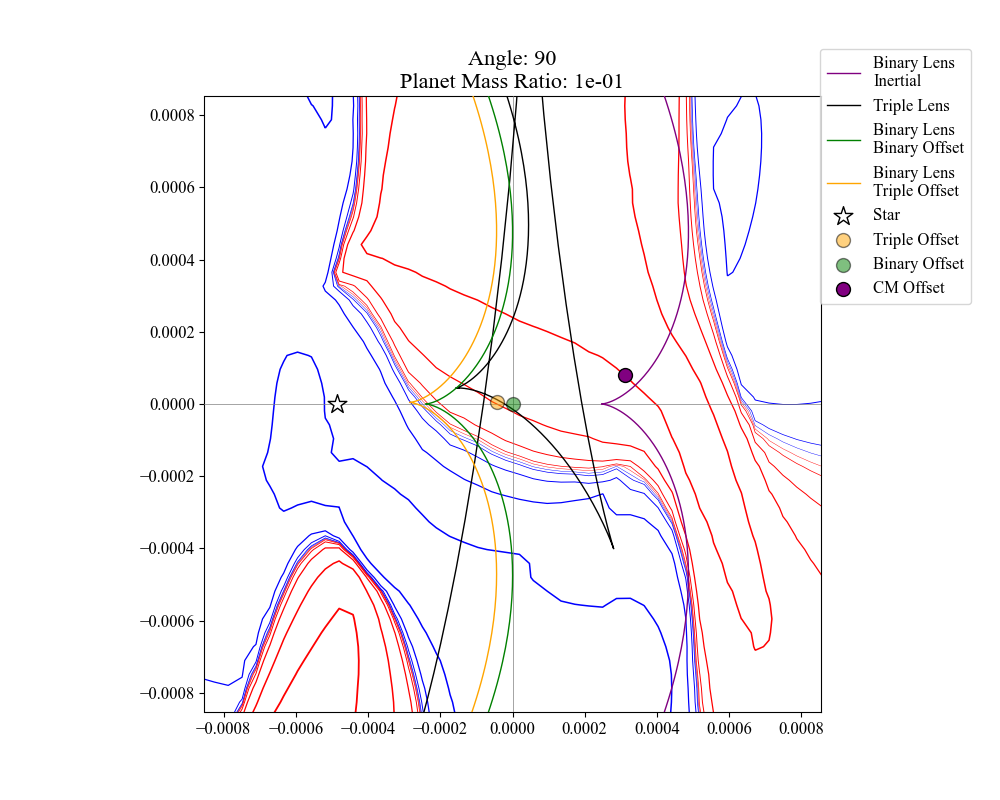

In [49]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

# fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for Binary Offset', y=0.98)

binary_lens_attributes_binary_offset = binary_lens_attributes.copy()
binary_lens_attributes_binary_offset[:, :2] -= binary_offsets[i, j]

binary_lens_attributes_triple_offset = binary_lens_attributes.copy()
binary_lens_attributes_triple_offset[:, :2] -= triple_offsets[i, j]

print(binary_lens_attributes)
print(binary_lens_attributes_binary_offset)
print(binary_lens_attributes_triple_offset)

i = 0
j = 2

ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

caustic_points = all_caustic_points[i][j]
if j == 0:
    num = 4
elif j == 2:
    num = 4
else:
    num = 3

caustic = binary_caustic_points_inertial[2]
ax.plot(caustic[0], caustic[1], color='purple', linewidth=1, zorder=10, label='Binary Lens\nInertial')

caustic = caustic_points[num]
ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10, label='Triple Lens')

# binary_caustic_points_binary_offset = binary_all_caustic_points_binary_offset[i][j]
# caustic = binary_caustic_points_binary_offset[2]
# ax.plot(caustic[0], caustic[1], color='green', linewidth=1, zorder=10, label='Binary Lens\nBinary Offset')
caustic = binary_caustic_points_inertial[2]
ax.plot(caustic[0] - binary_offsets[i, j, 0], caustic[1] - binary_offsets[i, j, 1], color='green', linewidth=1, zorder=10, label='Binary Lens\nBinary Offset')

# binary_caustic_points_triple_offset = binary_all_caustic_points_triple_offset[i][j]
# # for caustic in binary_caustic_points_triple_offset:
# caustic = binary_caustic_points_triple_offset[2]
# ax.plot(caustic[0], caustic[1], color="orange", linewidth=1, zorder=10, label='Binary Lens\nTriple Offset')
caustic = binary_caustic_points_inertial[2]
ax.plot(caustic[0] + triple_offsets[i, j, 0] - 2*binary_offsets[i, j, 0], caustic[1] + triple_offsets[i, j, 1] - 2*binary_offsets[i, j, 1], color='orange', linewidth=1, zorder=10, label='Binary Lens\nTriple Offset')

img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_binary_offset[i, j], axis=0),
        levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
        colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
        linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
        zorder=0
)

print(binary_offsets[i, j])
print(triple_offsets[i, j])

ax.scatter(single_lens.lens_att[:, 0] - binary_offsets[i, j, 0], single_lens.lens_att[:, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='white', marker='*', s=200, zorder=20, label='Star')
ax.scatter(triple_offsets[i, j, 0] - binary_offsets[i, j, 0], triple_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='orange', marker='o', s=100, zorder=20, alpha=0.5, label='Triple Offset')
ax.scatter(binary_offsets[i, j, 0] - binary_offsets[i, j, 0], binary_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='green', marker='o', s=100, zorder=20, alpha=0.5, label='Binary Offset')
ax.scatter(cm_offsets[i, j, 0] - binary_offsets[i, j, 0], cm_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='purple', marker='o', s=100, zorder=20, label='CM Offset')

ax.set_xlim(-ang_width/90, ang_width/90)
ax.set_ylim(-ang_width/90, ang_width/90)

ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, zorder=5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, zorder=5)

ax.set_aspect('equal')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.82, 0.62), ncol=1, fontsize=12)

plt.show()

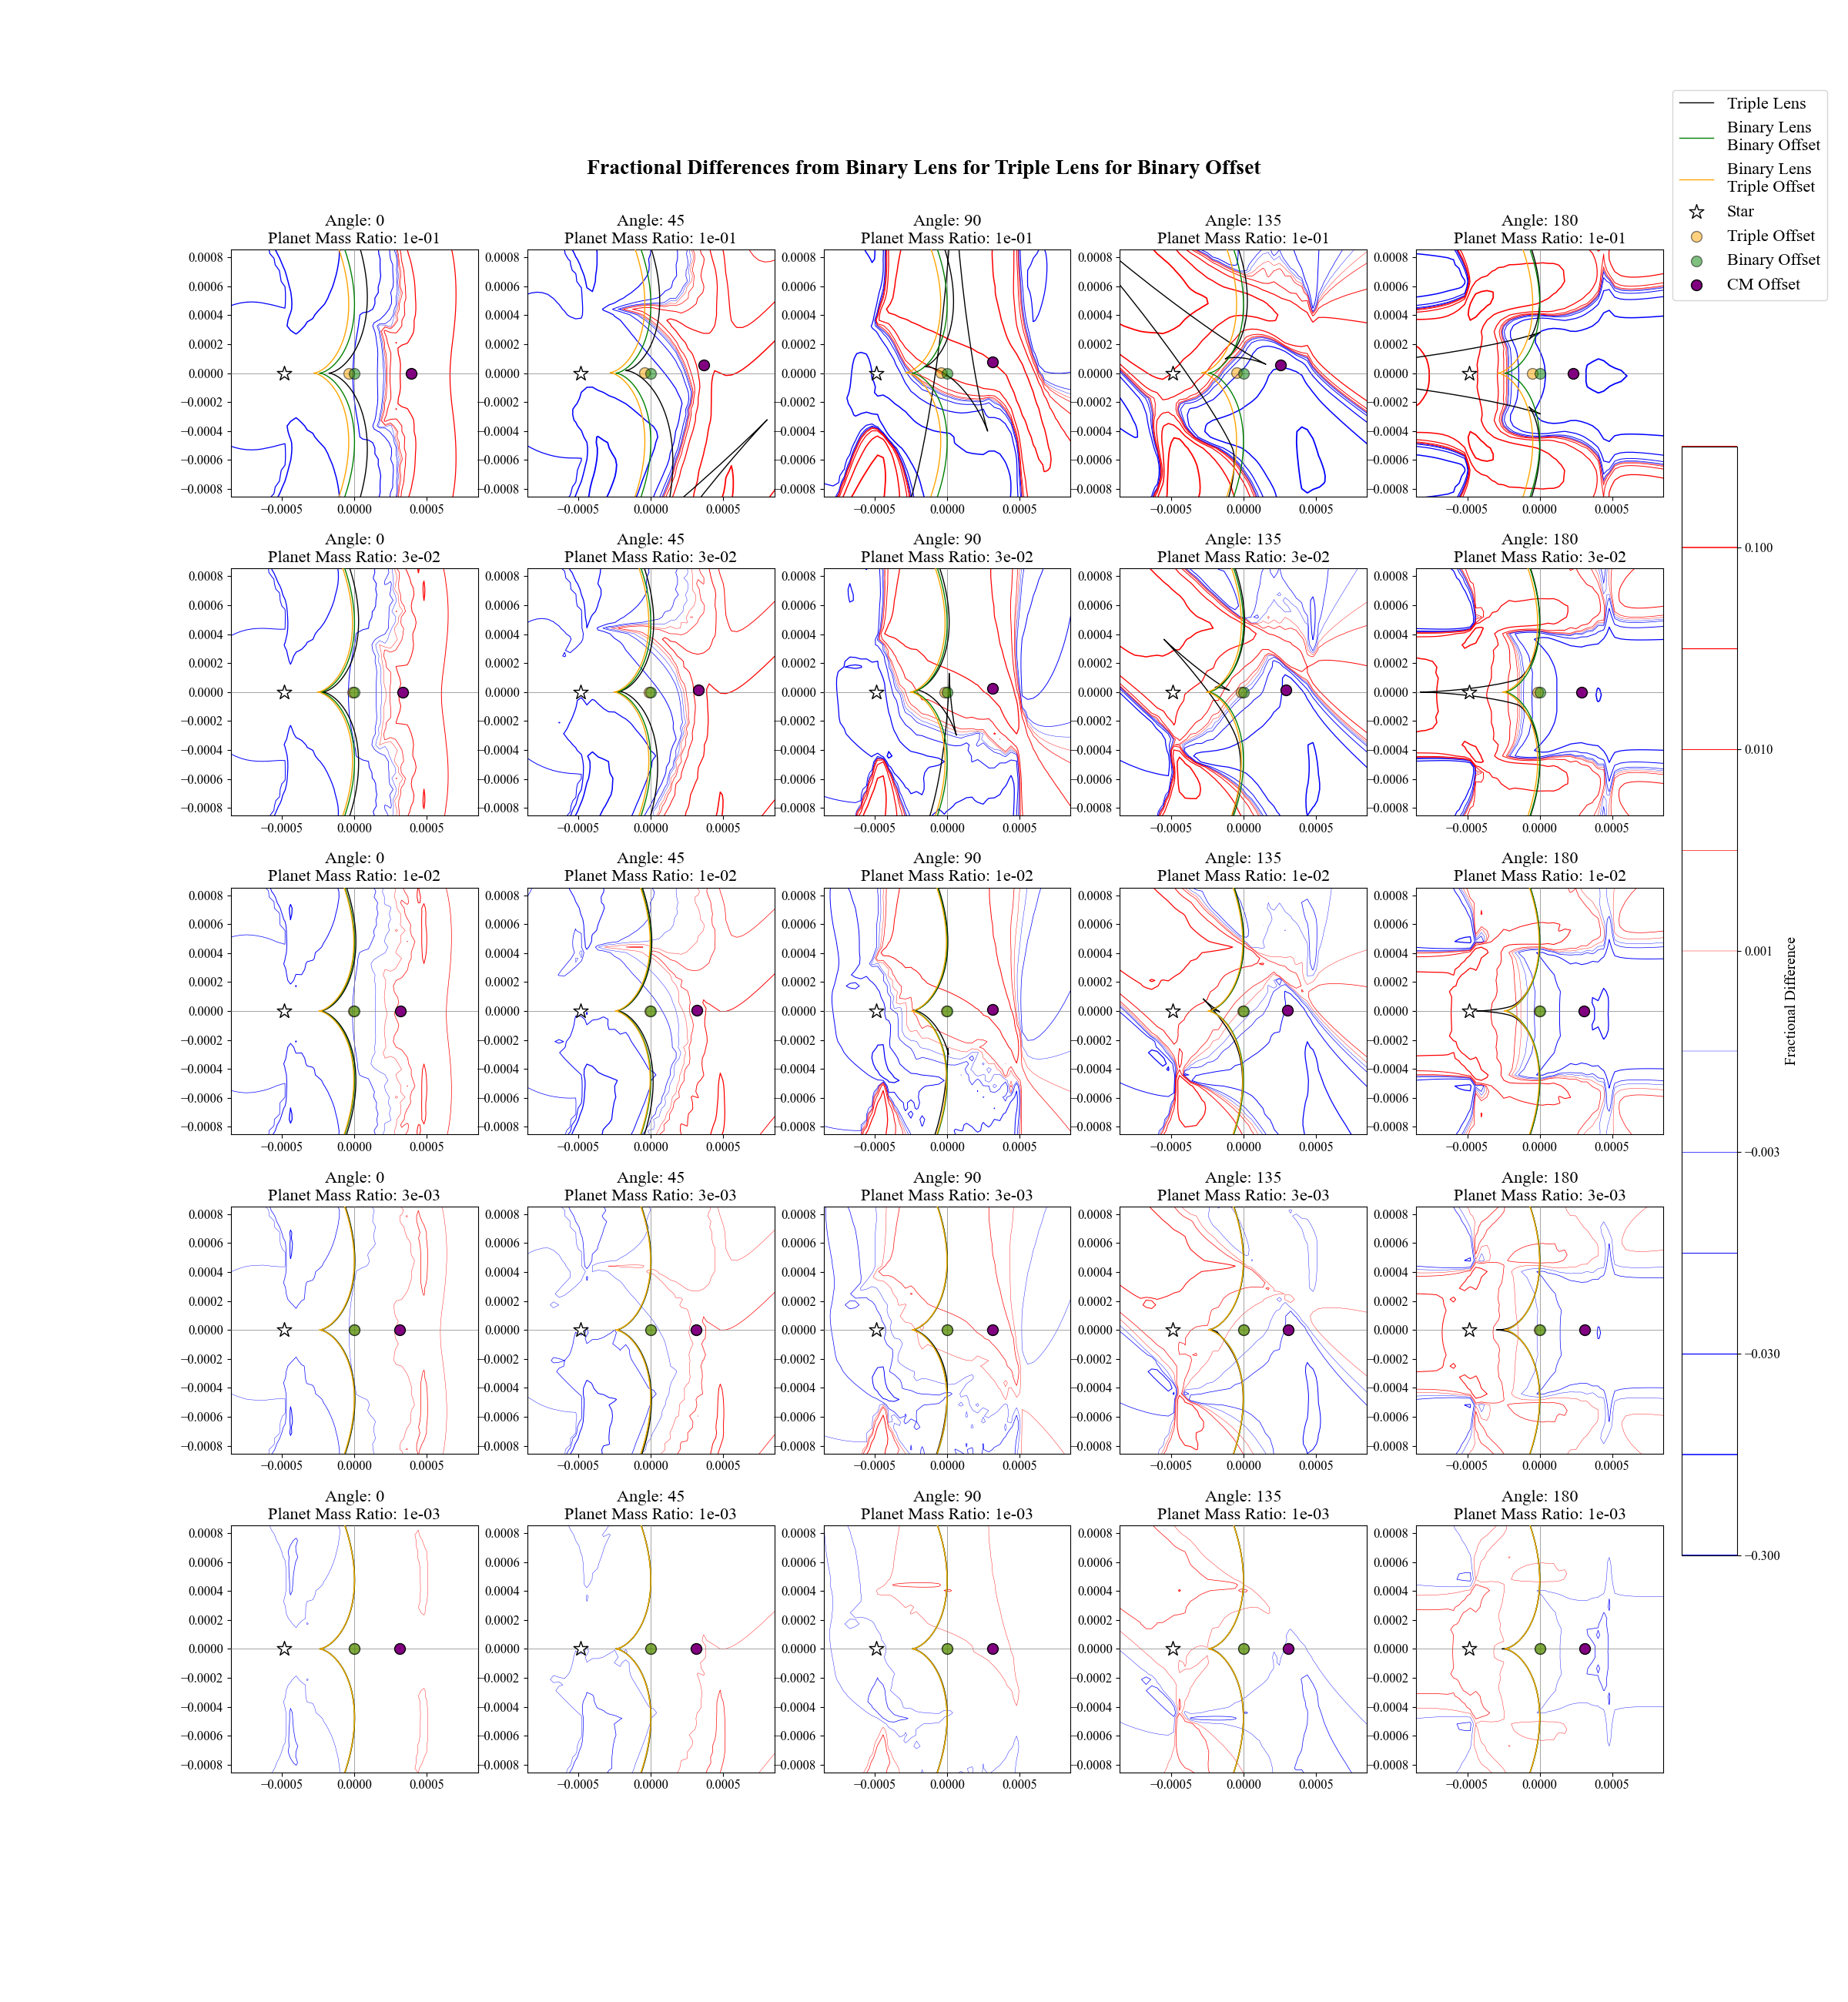

In [50]:
fig = plt.figure(figsize=(24, 26))
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for Binary Offset', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points[i][j]
        if j == 0:
            num = 4
        elif j == 2:
            num = 4
        else:
            num = 3
        # for caustic in caustic_points:
        caustic = caustic_points[num]
        ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10, label='Triple Lens')

        binary_caustic_points_binary_offset = binary_all_caustic_points_binary_offset[i][j]
        # for caustic in binary_caustic_points_binary_offset:
        caustic = binary_caustic_points_binary_offset[2]
        ax.plot(caustic[0], caustic[1], color='green', linewidth=1, zorder=10, label='Binary Lens\nBinary Offset')

        binary_caustic_points_triple_offset = binary_all_caustic_points_triple_offset[i][j]
        # for caustic in binary_caustic_points_triple_offset:
        caustic = binary_caustic_points_triple_offset[2]
        ax.plot(caustic[0], caustic[1], color='orange', linewidth=1, zorder=10, label='Binary Lens\nTriple Offset')

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_binary_offset[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )        

        ax.scatter(single_lens.lens_att[:, 0] - binary_offsets[i, j, 0], single_lens.lens_att[:, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='white', marker='*', s=200, zorder=20, label='Star')
        ax.scatter(triple_offsets[i, j, 0] - binary_offsets[i, j, 0], triple_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='orange', marker='o', s=100, zorder=20, alpha=0.5, label='Triple Offset')
        ax.scatter(binary_offsets[i, j, 0] - binary_offsets[i, j, 0], binary_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='green', marker='o', s=100, zorder=20, alpha=0.5, label='Binary Offset')
        ax.scatter(cm_offsets[i, j, 0] - binary_offsets[i, j, 0], cm_offsets[i, j, 1] - binary_offsets[i, j, 1], edgecolor='black', facecolor='purple', marker='o', s=100, zorder=20, label='CM Offset')

        ax.set_xlim(-ang_width/90, ang_width/90)
        ax.set_ylim(-ang_width/90, ang_width/90)

        ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, zorder=5)
        ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, zorder=5)

        ax.set_aspect('equal')
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

handles, labels = axes[1, 4].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.905, 0.85), ncol=1, fontsize=16)

# fig.savefig('Fractional Difference Contours Binary Offset Zoomed.png', dpi=500)


plt.show()

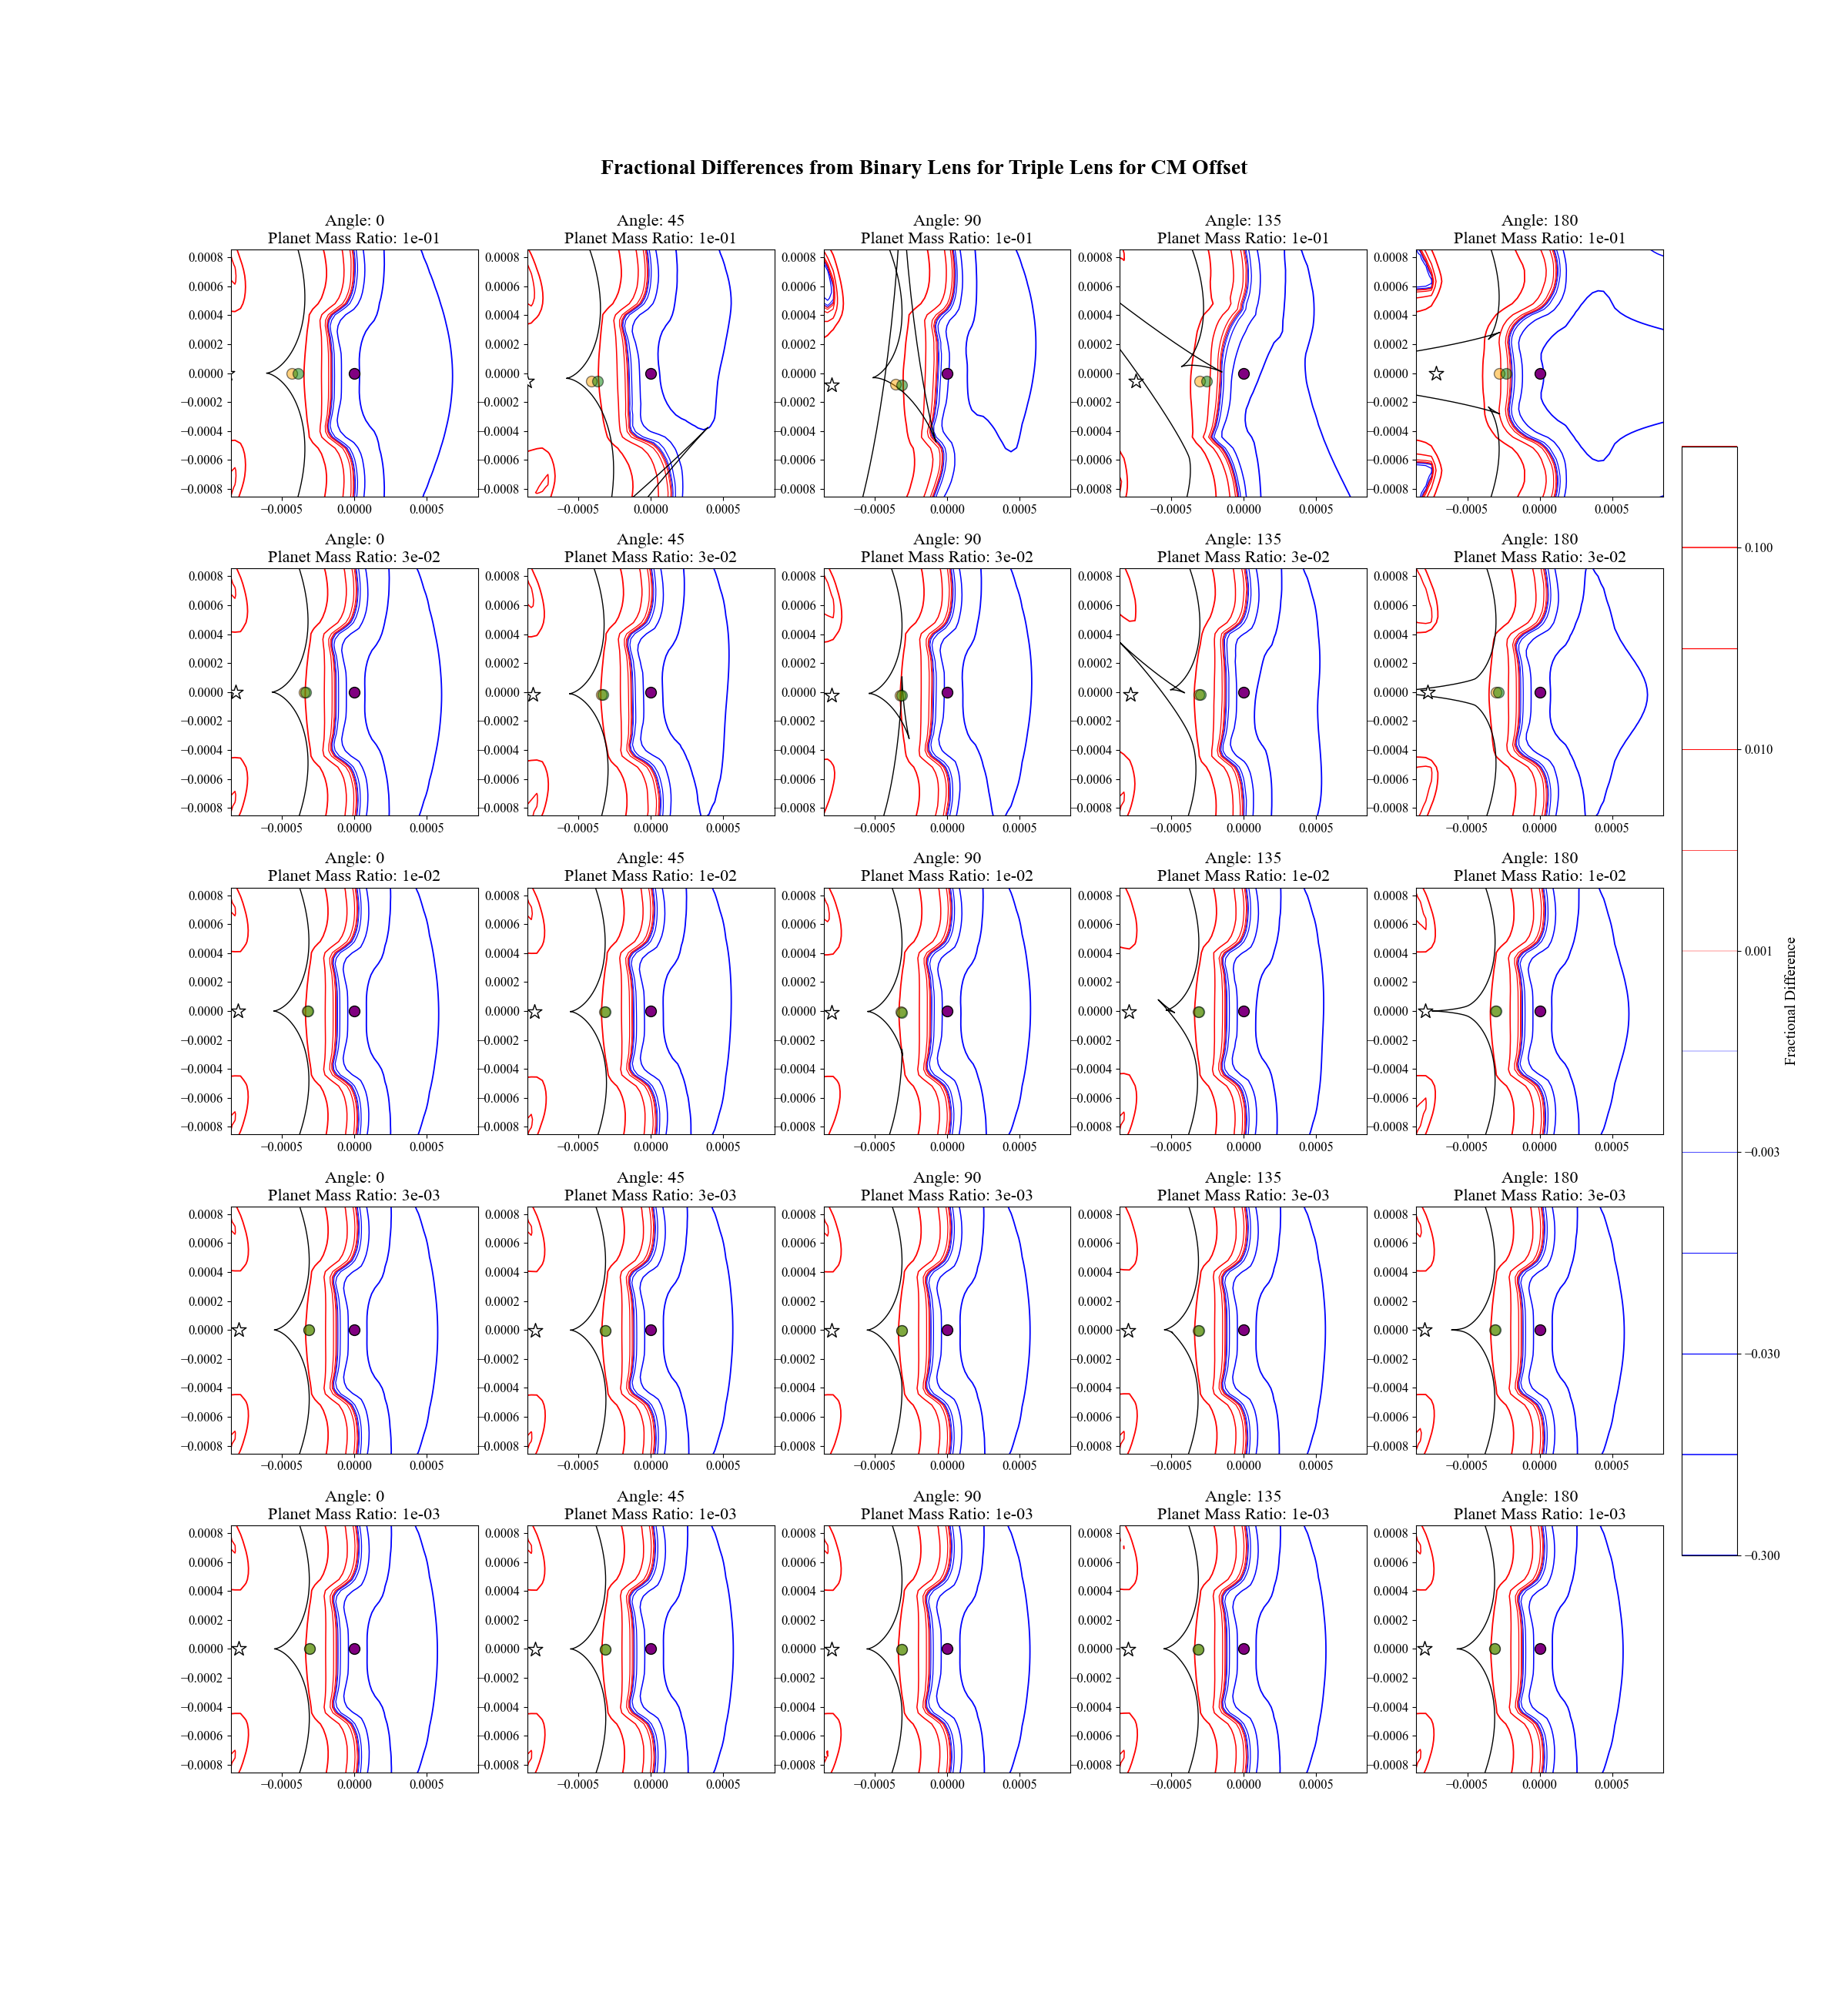

In [51]:
fig = plt.figure(figsize=(24, 26))
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle('Fractional Differences from Binary Lens for Triple Lens for CM Offset', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points_cm_offset[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_cm_offset[i, j], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        # ax.set_xlim(-ang_width/2, ang_width/2)
        # ax.set_ylim(-ang_width/2, ang_width/2)

        ax.scatter(single_lens.lens_att[:, 0] - cm_offsets[i, j, 0], single_lens.lens_att[:, 1] - cm_offsets[i, j, 1], edgecolor='black', facecolor='white', marker='*', s=200, zorder=20)
        ax.scatter(triple_offsets[i, j, 0] - cm_offsets[i, j, 0], triple_offsets[i, j, 1] - cm_offsets[i, j, 1], edgecolor='black', facecolor='orange', marker='o', s=100, zorder=20, alpha=0.5)
        ax.scatter(binary_offsets[i, j, 0] - cm_offsets[i, j, 0], binary_offsets[i, j, 1] - cm_offsets[i, j, 1], edgecolor='black', facecolor='green', marker='o', s=100, zorder=20, alpha=0.5)
        ax.scatter(cm_offsets[i, j, 0] - cm_offsets[i, j, 0], cm_offsets[i, j, 1] - cm_offsets[i, j, 1], edgecolor='black', facecolor='purple', marker='o', s=100, zorder=20)

        ax.set_xlim(-ang_width/90, ang_width/90)
        ax.set_ylim(-ang_width/90, ang_width/90)

        ax.set_aspect('equal')
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Contours CM Offset Zoomed.png', dpi=500)

plt.show()

#### Calculating cumulative distributions to determine the best offset

In [52]:
xs = np.logspace(-7, 0, 100)

cumulative_area_distribution = []
cumulative_area_distribution_binary_offset = []
cumulative_area_distribution_cm_offset = []

for x in xs:
    cumulative_area_distribution.append(np.sum(np.abs(fractional_deviation_binary) < x, axis=(2, 3)) / (pixels**2))
    cumulative_area_distribution_binary_offset.append(np.sum(np.abs(fractional_deviation_binary_binary_offset) < x, axis=(2, 3)) / (pixels**2))
    cumulative_area_distribution_cm_offset.append(np.sum(np.abs(fractional_deviation_binary_cm_offset) < x, axis=(2, 3)) / (pixels**2))

cumulative_area_distribution = np.array(cumulative_area_distribution)
cumulative_area_distribution_binary_offset = np.array(cumulative_area_distribution_binary_offset)
cumulative_area_distribution_cm_offset = np.array(cumulative_area_distribution_cm_offset)

#### Plotting cumulative area distributions

In [53]:
print(cumulative_area_distribution.shape)

(100, 5, 5)


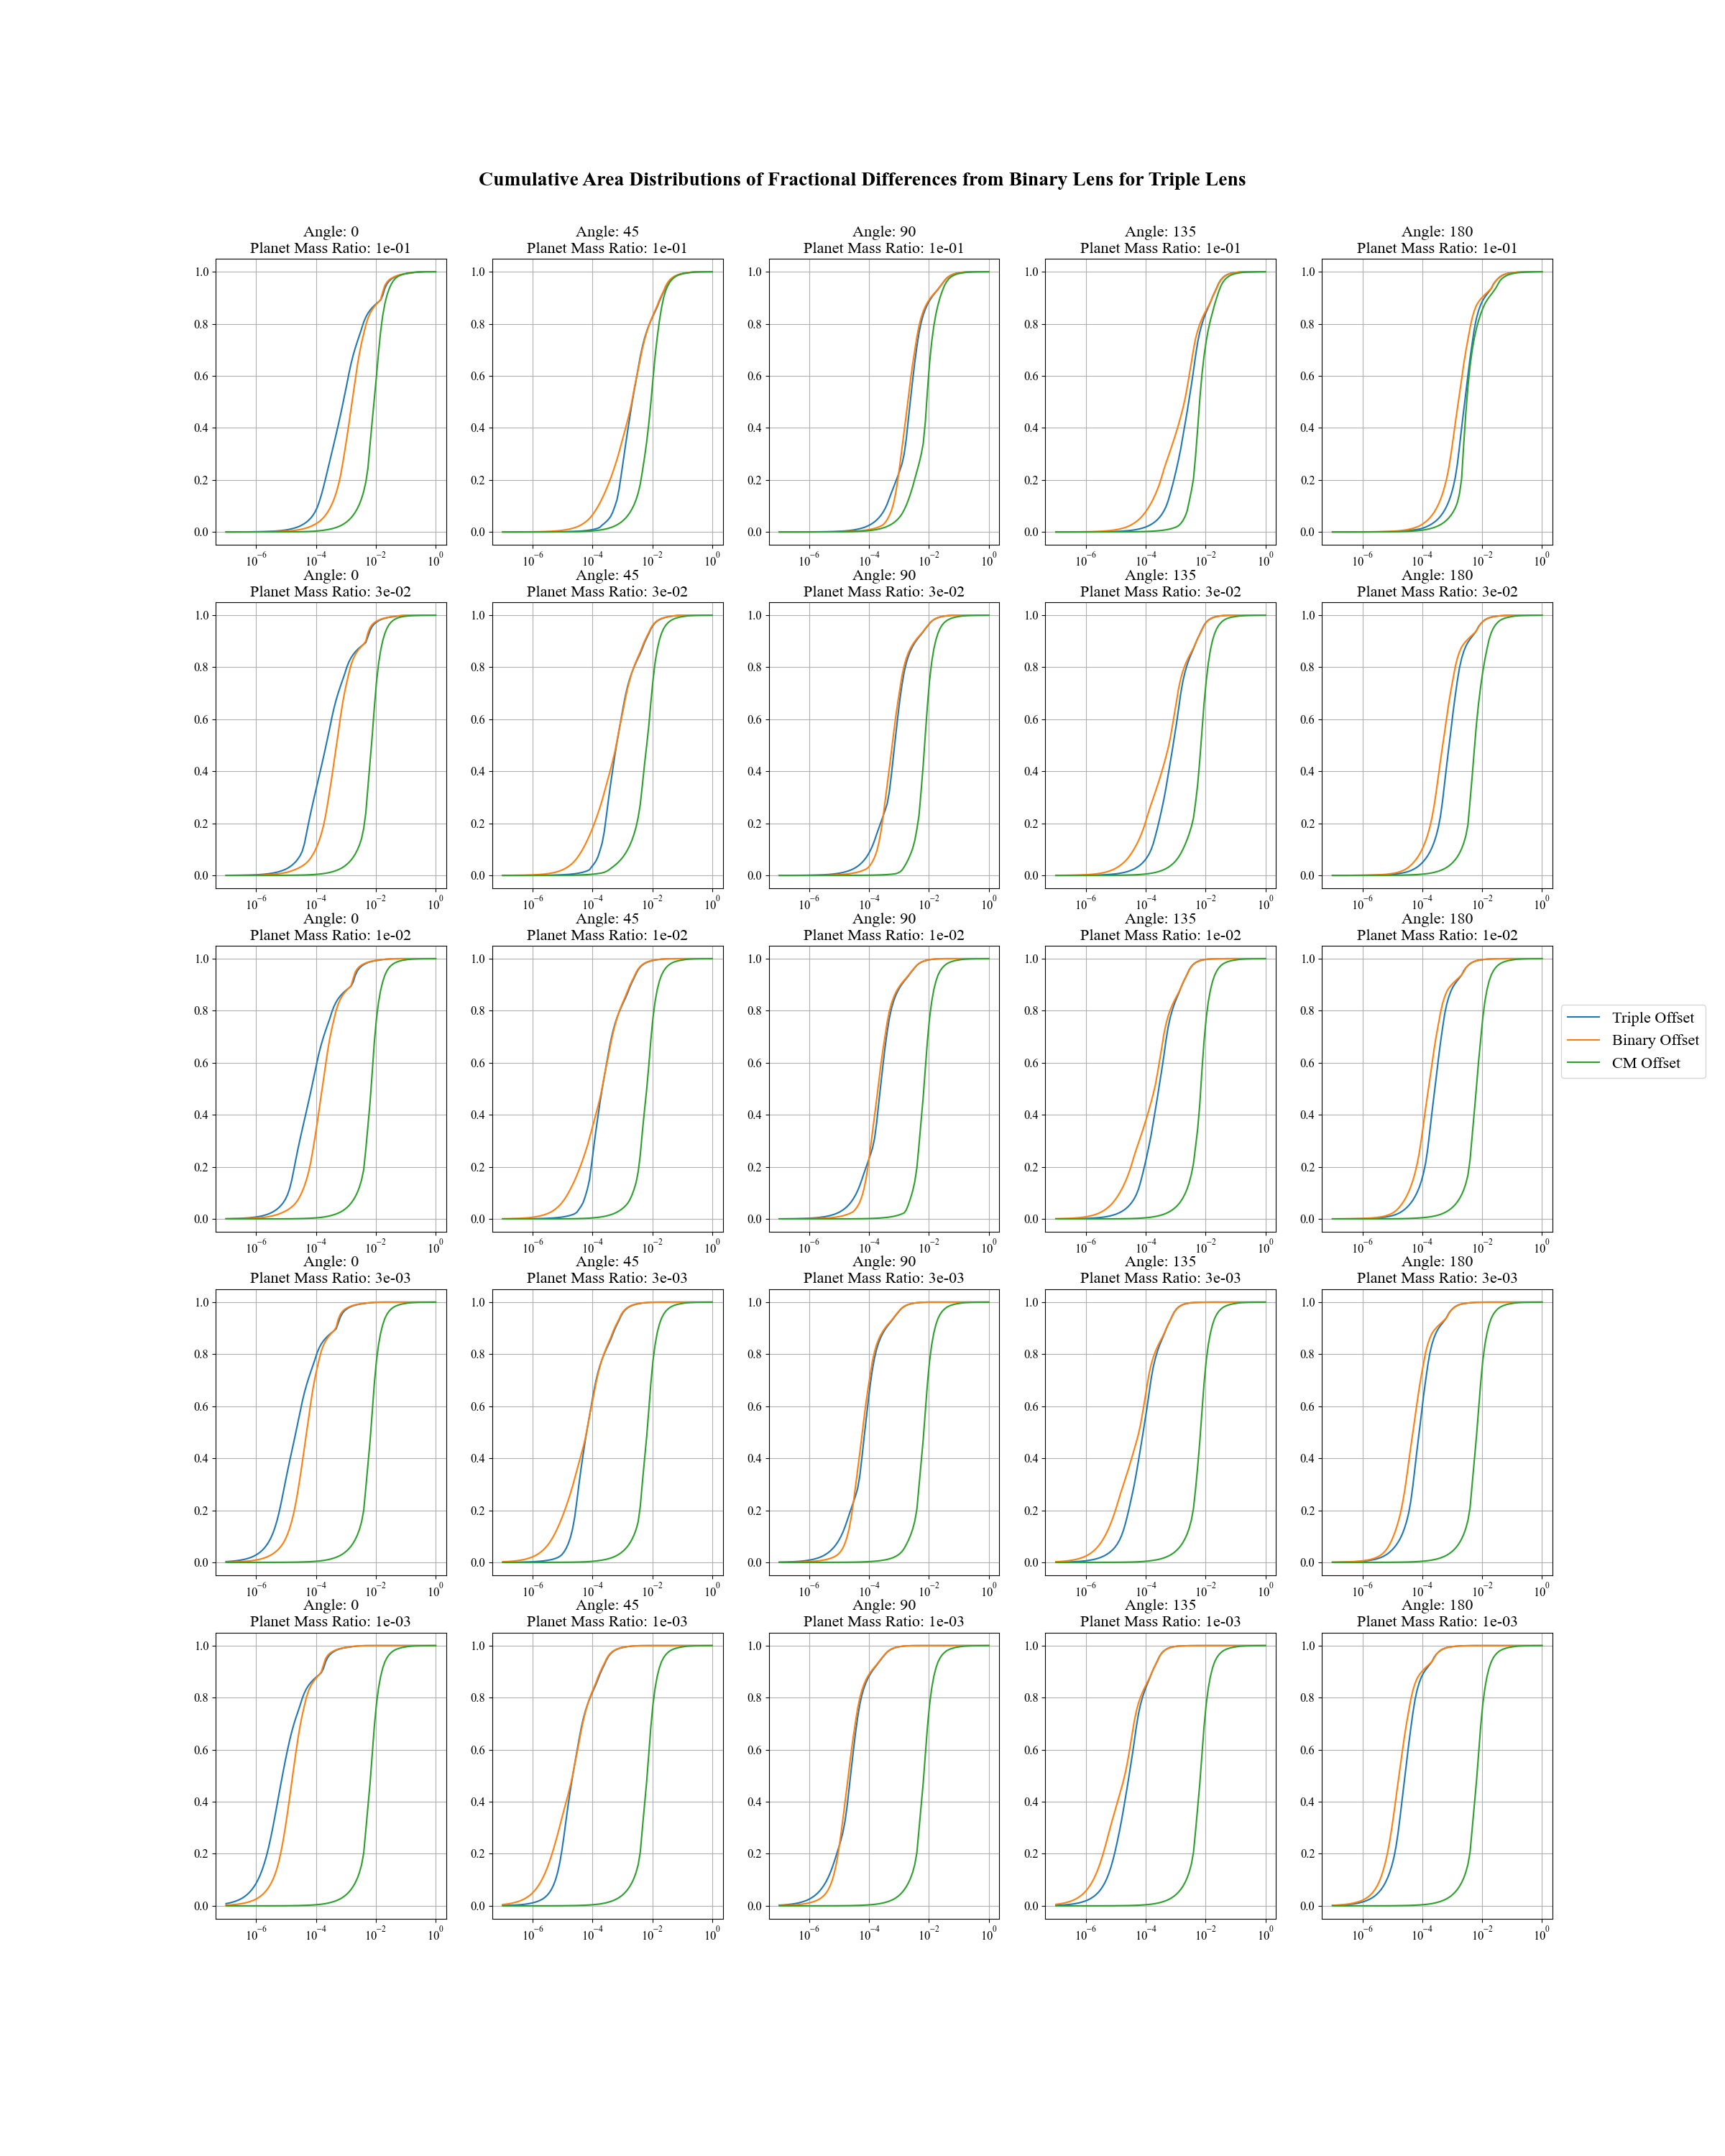

In [54]:
fig = plt.figure(figsize=(24, 30))
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle('Cumulative Area Distributions of Fractional Differences from Binary Lens for Triple Lens', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        ax.plot(xs, cumulative_area_distribution[:, i, j], label='Triple Offset')
        ax.plot(xs, cumulative_area_distribution_binary_offset[:, i, j], label='Binary Offset')
        ax.plot(xs, cumulative_area_distribution_cm_offset[:, i, j], label='CM Offset')

        ax.set_xscale('log')
        ax.grid(True)
        # ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.905, 0.5), ncol=1, fontsize=16)

# fig.savefig('Cumulative Area Distribution Triple Lens.png', dpi=500)

plt.show()

In [55]:
xs = np.array([1e-4, 1e-3, 1e-2])

cumulative_area_distribution = []
cumulative_area_distribution_binary_offset = []
cumulative_area_distribution_cm_offset = []

for x in xs:
    constant_xs = []
    constant_xs_binary_offset = []
    constant_xs_cm_offset = []

    for i in range(len(pmrs)):
        constant_pmr = []
        constant_pmr_binary_offset = []
        constant_pmr_cm_offset = []

        for j in range(len(betas)):
            constant_pmr.append(np.sum(np.abs(fractional_deviation_binary[i, j]) < x) / (pixels**2))
            constant_pmr_binary_offset.append(np.sum(np.abs(fractional_deviation_binary_binary_offset[i, j]) < x) / (pixels**2))
            constant_pmr_cm_offset.append(np.sum(np.abs(fractional_deviation_binary_cm_offset[i, j]) < x) / (pixels**2))

        constant_xs.append(constant_pmr)
        constant_xs_binary_offset.append(constant_pmr_binary_offset)
        constant_xs_cm_offset.append(constant_pmr_cm_offset)
    
    cumulative_area_distribution.append(constant_xs)
    cumulative_area_distribution_binary_offset.append(constant_xs_binary_offset)
    cumulative_area_distribution_cm_offset.append(constant_xs_cm_offset)

cumulative_area_distribution = np.array(cumulative_area_distribution)
cumulative_area_distribution_binary_offset = np.array(cumulative_area_distribution_binary_offset)
cumulative_area_distribution_cm_offset = np.array(cumulative_area_distribution_cm_offset)

In [56]:
print(cumulative_area_distribution.shape)

(3, 5, 5)


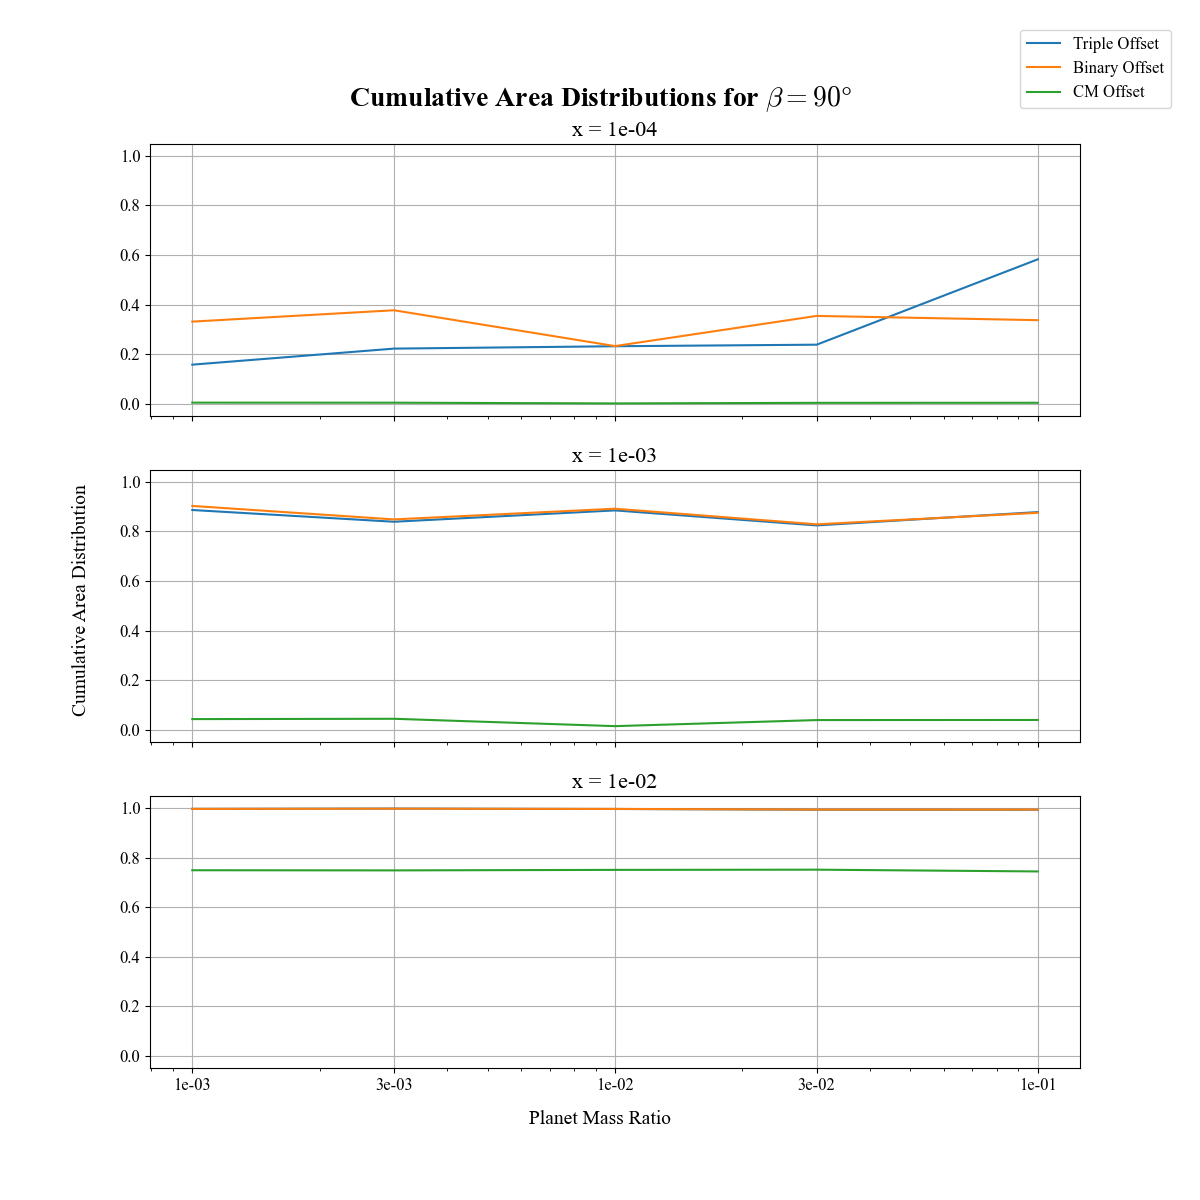

In [80]:
fig = plt.figure(figsize=(12, 12))
axes = fig.subplots(3, 1, sharex=True, sharey=True)

beta_ind = 2

fig.suptitle(f'Cumulative Area Distributions for $\\beta = {betas[beta_ind]}\degree$', y=0.93)

for i, ax in enumerate(axes):
    ax.set_title(f'x = {xs[i]:.0e}')

    ax.semilogx(pmrs, cumulative_area_distribution[i, beta_ind, :], label='Triple Offset')
    ax.semilogx(pmrs, cumulative_area_distribution_binary_offset[i, beta_ind, :], label='Binary Offset')
    ax.semilogx(pmrs, cumulative_area_distribution_cm_offset[i, beta_ind, :], label='CM Offset')

    ax.set_xticks(pmrs)
    ax.set_xticklabels([f'{pmr:.0e}' for pmr in pmrs])
    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.85, 0.91), ncol=1, fontsize=12)

fig.supxlabel('Planet Mass Ratio', y=0.06)
fig.supylabel('Cumulative Area Distribution', x=0.06)

fig.savefig('Cumulative Distributions Varying PMR.png', dpi=500)

plt.show()

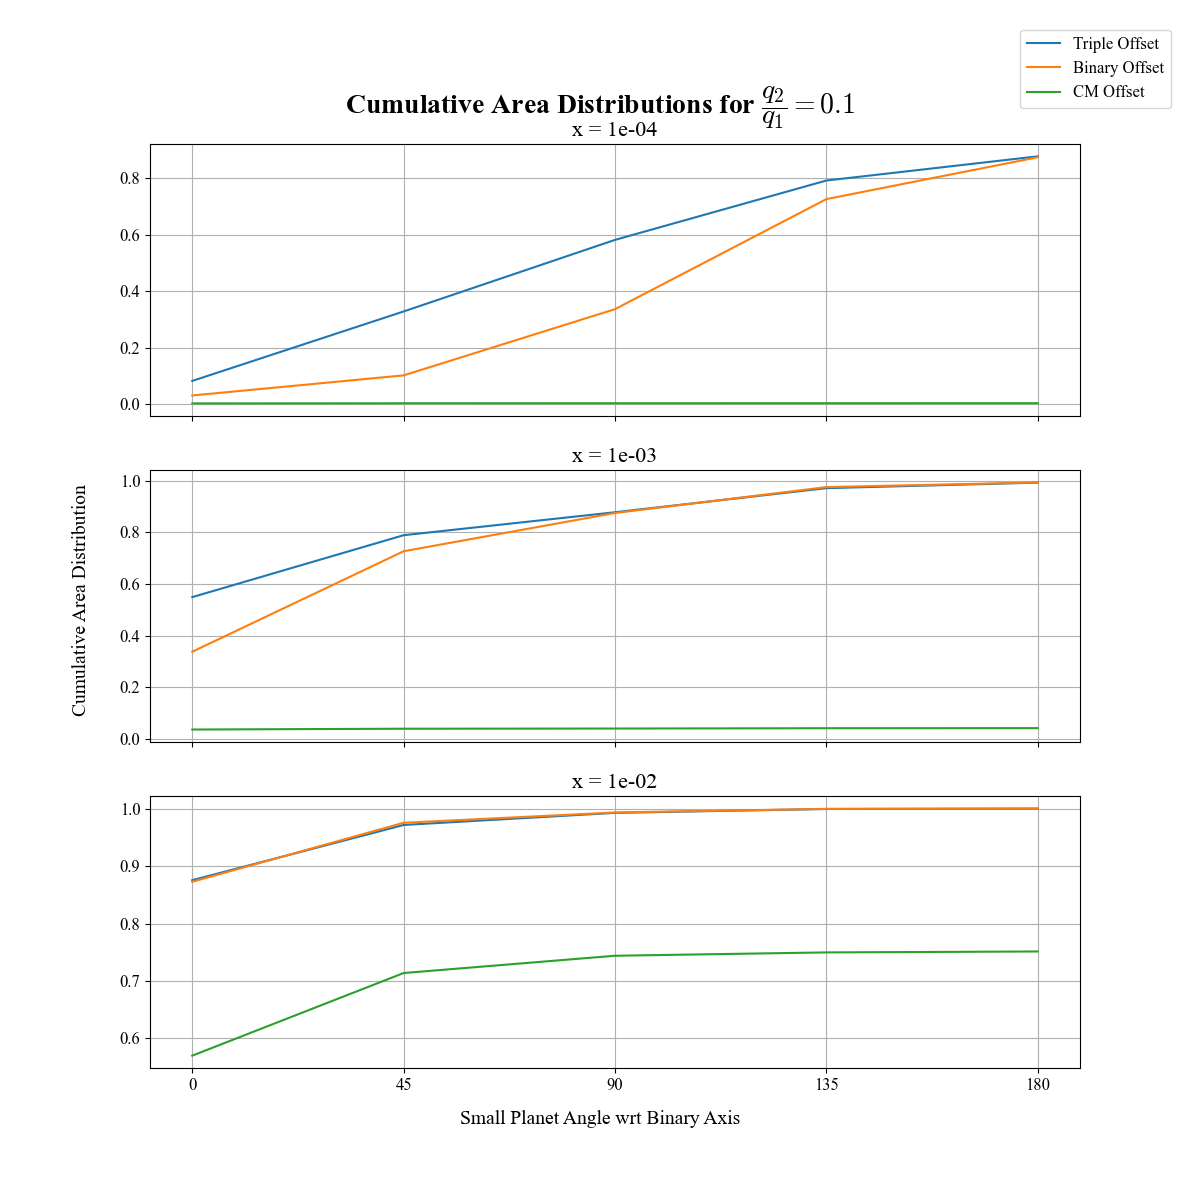

In [82]:
fig = plt.figure(figsize=(12, 12))
axes = fig.subplots(3, 1, sharex=True)

pmr_ind = 0

fig.suptitle('Cumulative Area Distributions for $\\dfrac{q_2}{q_1} = $' + f'${pmrs[pmr_ind]}$', y=0.93)

for i, ax in enumerate(axes):
    ax.set_title(f'x = {xs[i]:.0e}')

    ax.plot(betas, cumulative_area_distribution[i, :, pmr_ind], label='Triple Offset')
    ax.plot(betas, cumulative_area_distribution_binary_offset[i, :, pmr_ind], label='Binary Offset')
    ax.plot(betas, cumulative_area_distribution_cm_offset[i, :, pmr_ind], label='CM Offset')

    ax.set_xticks(betas)
    ax.set_xticklabels([f'{beta:.0f}' for beta in betas])
    ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.85, 0.91), ncol=1, fontsize=12)

fig.supxlabel('Small Planet Angle wrt Binary Axis', y=0.06)
fig.supylabel('Cumulative Area Distribution', x=0.06)

fig.savefig('Cumulative Distributions Varying Angle.png', dpi=500)

plt.show()

#### Generating light curves

In [78]:
# Distribution of impact parameters and angle with respect to binary axis
us = np.linspace(0, ang_width/2, 21)
alphas = np.linspace(-180, 180, 9)

print(us)
print(alphas)

brightness_distribution = []
brightness_distribution_binary_offset = []
brightness_distribution_cm_offset = []
binary_brightness_distribution = []

time_distribution = []
x_distribution = []
y_distribution = []

for i, row in enumerate(triple_lenses):
    constant_pmr = []
    constant_pmr_binary_offset = []
    constant_pmr_cm_offset = []
    binary_constant_pmr = []

    constant_pmr_times = []
    constant_pmr_x = []
    constant_pmr_y = []

    for j, triple_lens in enumerate(row):
        one_configuration = []
        one_configuration_binary_offset = []
        one_configuration_cm_offset = []
        binary_one_configuration = []

        one_configuration_times = []
        one_configuration_x = []
        one_configuration_y = []

        for u in us:
            constant_u = []
            constant_u_binary_offset = []
            constant_u_cm_offset = []
            binary_constant_u = []

            constant_u_times = []
            constant_u_x = []
            constant_u_y = []

            for alpha in alphas:
                intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses[i, j])
                constant_u.append(brightness)

                intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses_binary_offset[i, j])
                constant_u_binary_offset.append(brightness)
                
                intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_triple_lenses_cm_offset[i, j])
                constant_u_cm_offset.append(brightness)

                # if i == 0 and j == 0:
                intersections, (xs, ys), times, brightness = IRSC.IRSCaustics.lightcurve_calculator(u, alpha, ang_width, convolved_binary_lens)
                binary_constant_u.append(brightness)
                
                constant_u_times.append(times)
                constant_u_x.append(xs)
                constant_u_y.append(ys)

            one_configuration.append(constant_u)
            one_configuration_binary_offset.append(constant_u_binary_offset)
            one_configuration_cm_offset.append(constant_u_cm_offset)
            binary_one_configuration.append(binary_constant_u)

            one_configuration_times.append(constant_u_times)
            one_configuration_x.append(constant_u_x)
            one_configuration_y.append(constant_u_y)
        
        constant_pmr.append(one_configuration)
        constant_pmr_binary_offset.append(one_configuration_binary_offset)
        constant_pmr_cm_offset.append(one_configuration_cm_offset)
        binary_constant_pmr.append(binary_one_configuration)

        constant_pmr_times.append(one_configuration_times)
        constant_pmr_x.append(one_configuration_x)
        constant_pmr_y.append(one_configuration_y)

    brightness_distribution.append(constant_pmr)
    brightness_distribution_binary_offset.append(constant_pmr_binary_offset)
    brightness_distribution_cm_offset.append(constant_pmr_cm_offset)
    binary_brightness_distribution.append(binary_constant_pmr)

    time_distribution.append(constant_pmr_times)
    x_distribution.append(constant_pmr_x)
    y_distribution.append(constant_pmr_y)


[0.         0.00192008 0.00384016 0.00576024 0.00768032 0.0096004
 0.01152048 0.01344056 0.01536064 0.01728072 0.0192008  0.02112088
 0.02304096 0.02496104 0.02688112 0.0288012  0.03072128 0.03264136
 0.03456144 0.03648152 0.0384016 ]
[-180. -135.  -90.  -45.    0.   45.   90.  135.  180.]


/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: divide by zero encountered in scalar divide
  t = (y_edge - y0) / dy
/Users/saividyud/Documents/GitHub/NBLens/Unity Analysis/../IRSMicroLensing/IRSCaustics.py:1370: RuntimeWarning: invalid value encountered in scalar divide
  t = (y_edge - y0) / dy


In [79]:
brightness_distribution = np.array(brightness_distribution, dtype=np.ndarray)
brightness_distribution_binary_offset = np.array(brightness_distribution_binary_offset, dtype=np.ndarray)
brightness_distribution_cm_offset = np.array(brightness_distribution_cm_offset, dtype=np.ndarray)
binary_brightness_distribution = np.array(binary_brightness_distribution, dtype=np.ndarray)

time_distribution = np.array(time_distribution, dtype=np.ndarray)
x_distribution = np.array(x_distribution, dtype=np.ndarray)
y_distribution = np.array(y_distribution, dtype=np.ndarray)

print(brightness_distribution.shape)
print(brightness_distribution_binary_offset.shape)
print(brightness_distribution_cm_offset.shape)
print(binary_brightness_distribution.shape)

print(time_distribution.shape)
print(x_distribution.shape)
print(y_distribution.shape)

(5, 5, 21, 9)
(5, 5, 21, 9)
(5, 5, 21, 9)
(5, 5, 21, 9)
(5, 5, 21, 9)
(5, 5, 21, 9)
(5, 5, 21, 9)


#### VBMicrolensing binary light curves

In [80]:
VB_magnifications = []
VB_xs = []
VB_ys = []

# Calculating light curve for binary lens
for i, u in enumerate(us):
    constant_u = []
    constant_u_xs = []
    constant_u_ys = []

    for j, alpha in enumerate(alphas):
        s = 0.8
        q = 1e-3
        u0 = -u
        alpha = np.deg2rad(alpha)
        rho = radius / 10
        tE = 1.0
        t0 = 0

        # Array of parameters for the light curve
        parameters = [np.log(s), np.log(q), u0, alpha, np.log(rho), np.log(tE), t0]

        t = np.flip(time_distribution[0, 0][i, j])
        # t = np.linspace(-1, 1, 1000)

        magnification, y1, y2 = VBM.BinaryLightCurve(parameters, t)
        constant_u.append(magnification)
        constant_u_xs.append(y1)
        constant_u_ys.append(y2)
    
    VB_magnifications.append(constant_u)
    VB_xs.append(constant_u_xs)
    VB_ys.append(constant_u_ys)

#### Choosing what light curve to plot

In [81]:
one_curve = True

ind_u = 1
ind_alpha = 5

print(f'u = {us[ind_u]:.5f}')
print(f'alpha = {alphas[ind_alpha]:.3f} degrees')

u = 0.00192
alpha = 45.000 degrees


[-0.03840159840159841, -0.03836315118118359, -0.03832470396076875, -0.03828625674035393, -0.03824780951993909, -0.03820936229952426, -0.03817091507910943, -0.038132467858694605, -0.03809402063827977, -0.03805557341786493, -0.0380171261974501, -0.03797867897703528, -0.037940231756620445, -0.03790178453620561, -0.03786333731579078, -0.03782489009537596, -0.03778644287496112, -0.037747995654546285, -0.037709548434131455, -0.03767110121371663, -0.0376326539933018, -0.03759420677288696, -0.03755575955247213, -0.0375173123320573, -0.03747886511164247, -0.03744041789122764, -0.03740197067081281, -0.03736352345039797, -0.03732507622998315, -0.03728662900956831, -0.037248181789153484, -0.03720973456873865, -0.037171287348323825, -0.03713284012790899, -0.03709439290749415, -0.037055945687079324, -0.0370174984666645, -0.036979051246249665, -0.03694060402583483, -0.03690215680542, -0.03686370958500518, -0.03682526236459034, -0.036786815144175505, -0.036748367923760676, -0.036709920703345854, -0.03

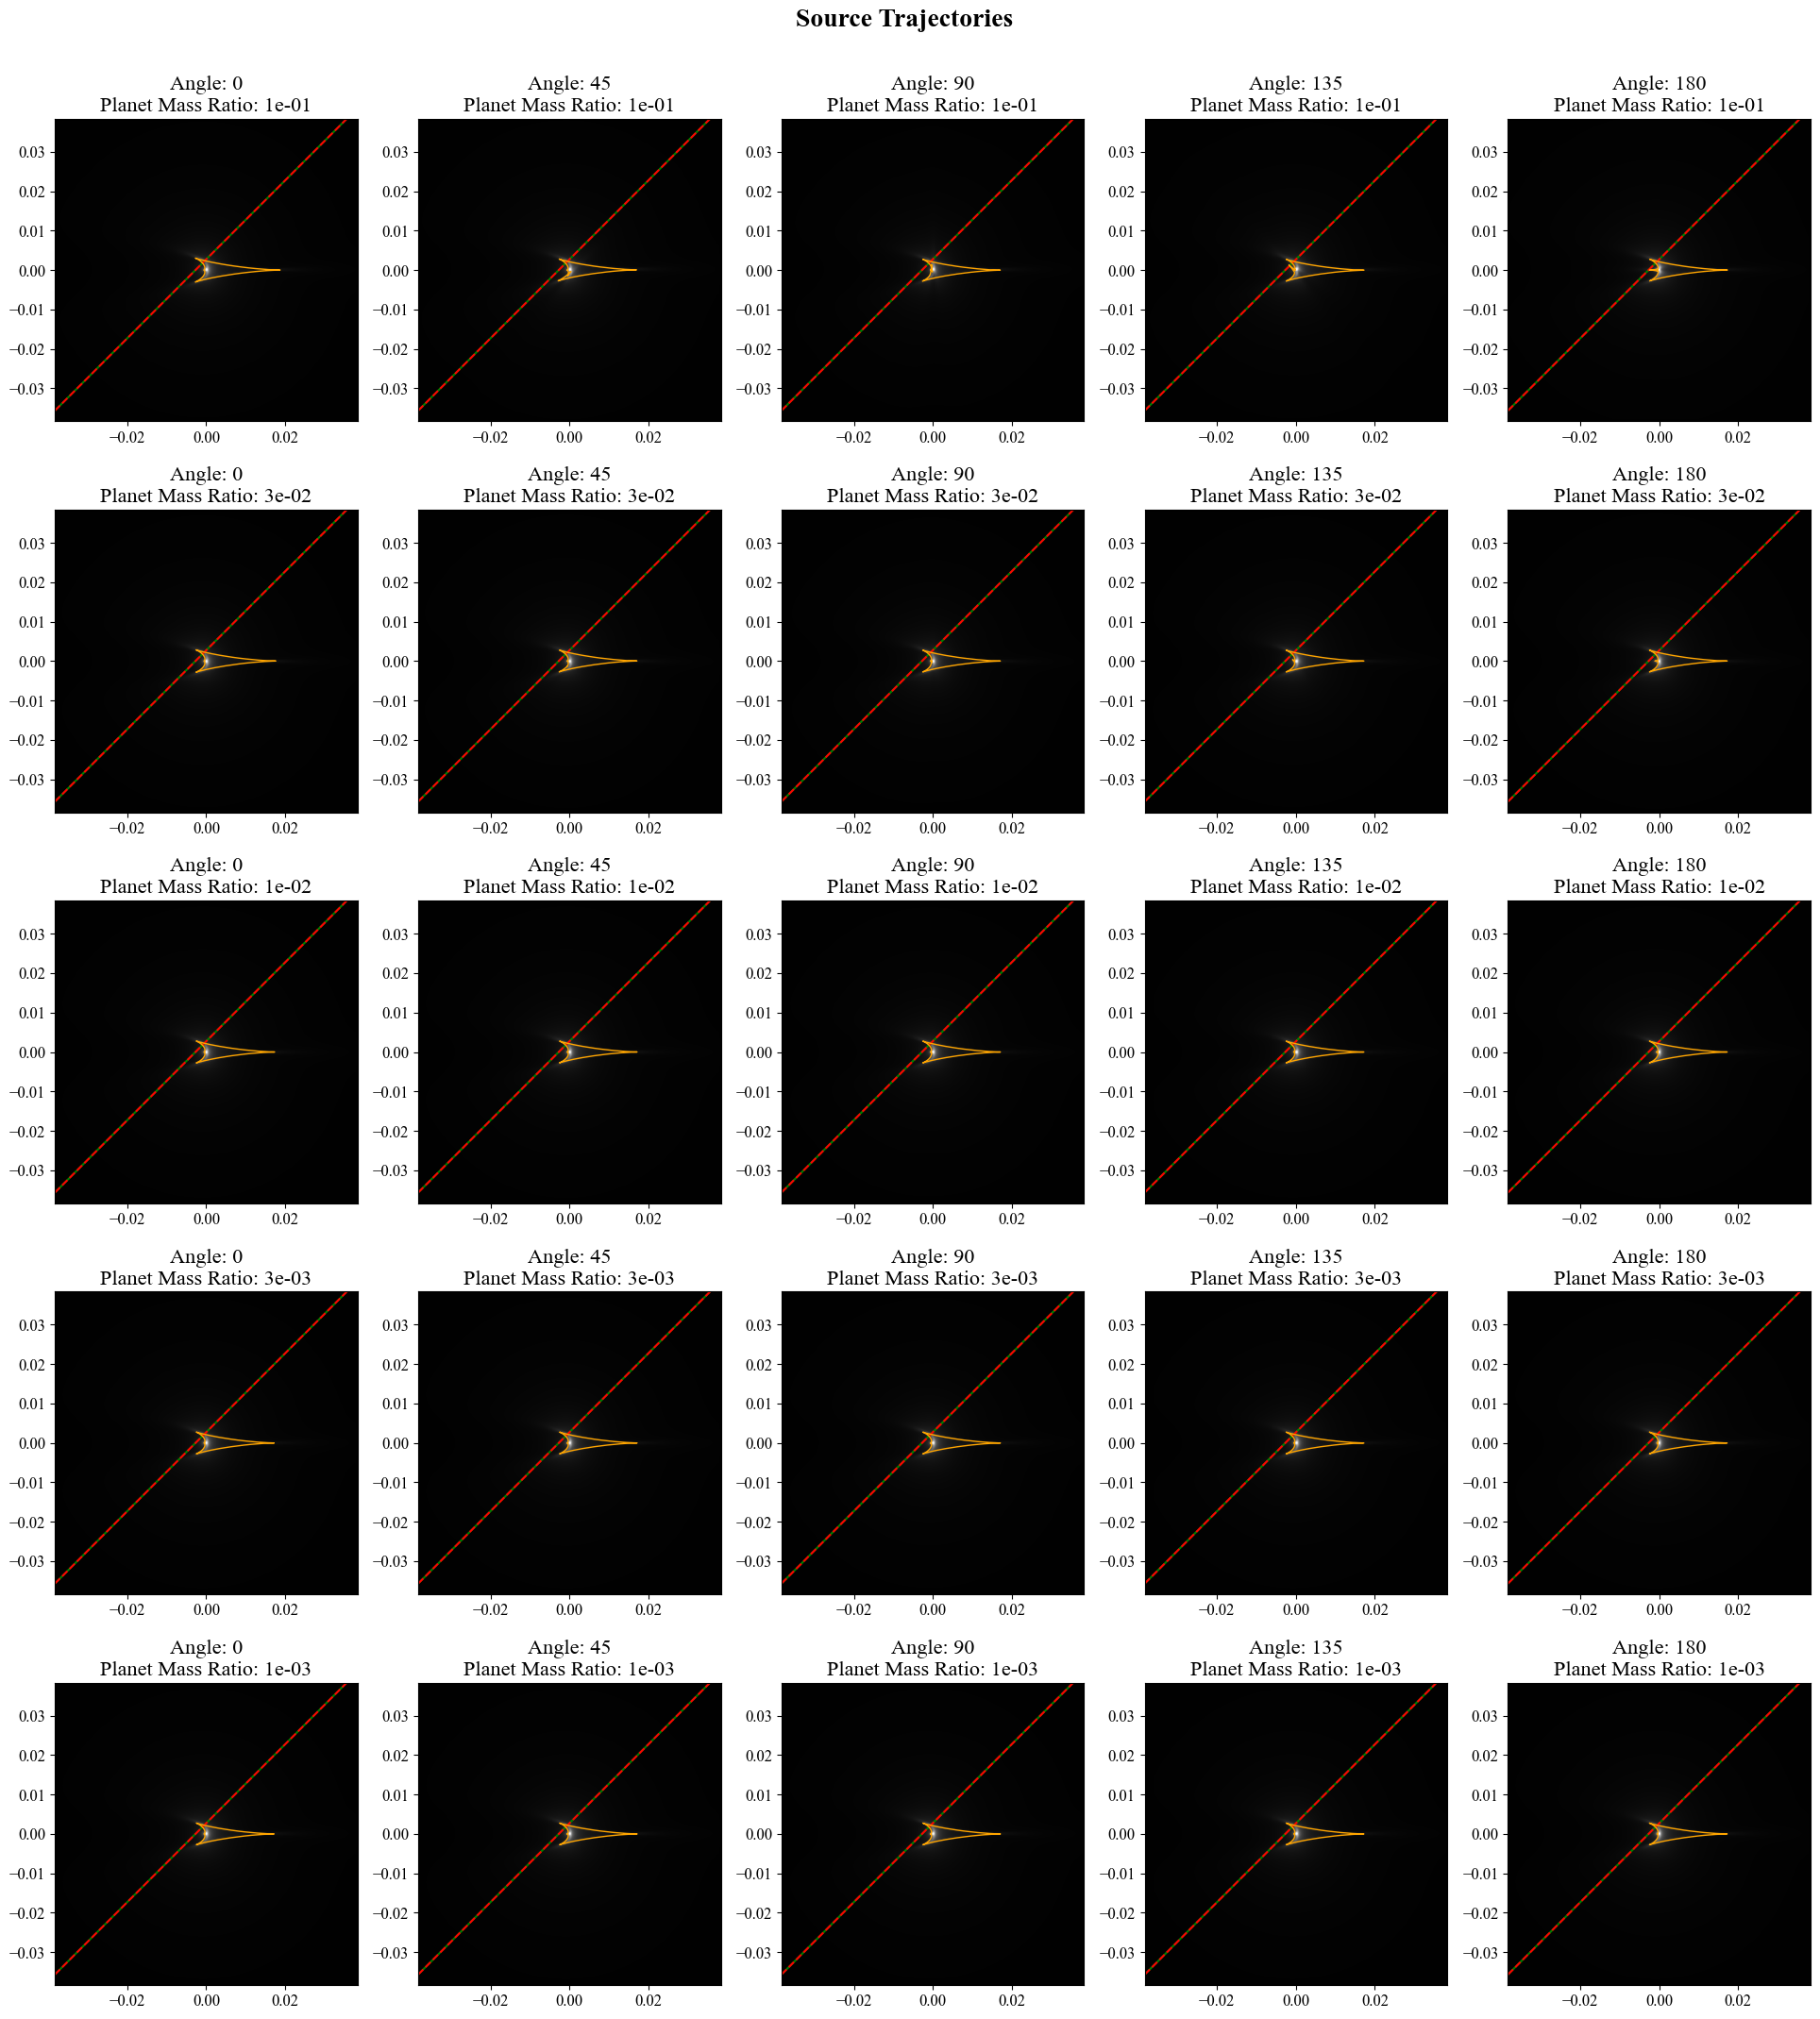

In [82]:
fig = plt.figure(figsize=(24, 26))
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle('Source Trajectories', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points_cm_offset[i][j]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='orange', linewidth=1, zorder=10)

        ax.imshow(convolved_triple_lenses[i, j], cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2])

        one_configuration_xs = x_distribution[i, j]
        one_configuration_ys = y_distribution[i, j]
        
        if one_curve:
            xs = one_configuration_xs[ind_u, ind_alpha]
            ys = one_configuration_ys[ind_u, ind_alpha]

            ax.plot(xs, ys, color='green')
            ax.plot(VB_xs[ind_u][ind_alpha], VB_ys[ind_u][ind_alpha], linestyle='--', color='red')
            print(VB_xs[ind_u][ind_alpha])

        else:
            for ind_u in range(len(us)):
                for ind_alpha in range(len(alphas)):
                    xs = one_configuration_xs[ind_u, ind_alpha]
                    ys = one_configuration_ys[ind_u, ind_alpha]

                    ax.plot(xs, ys, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)

plt.show()

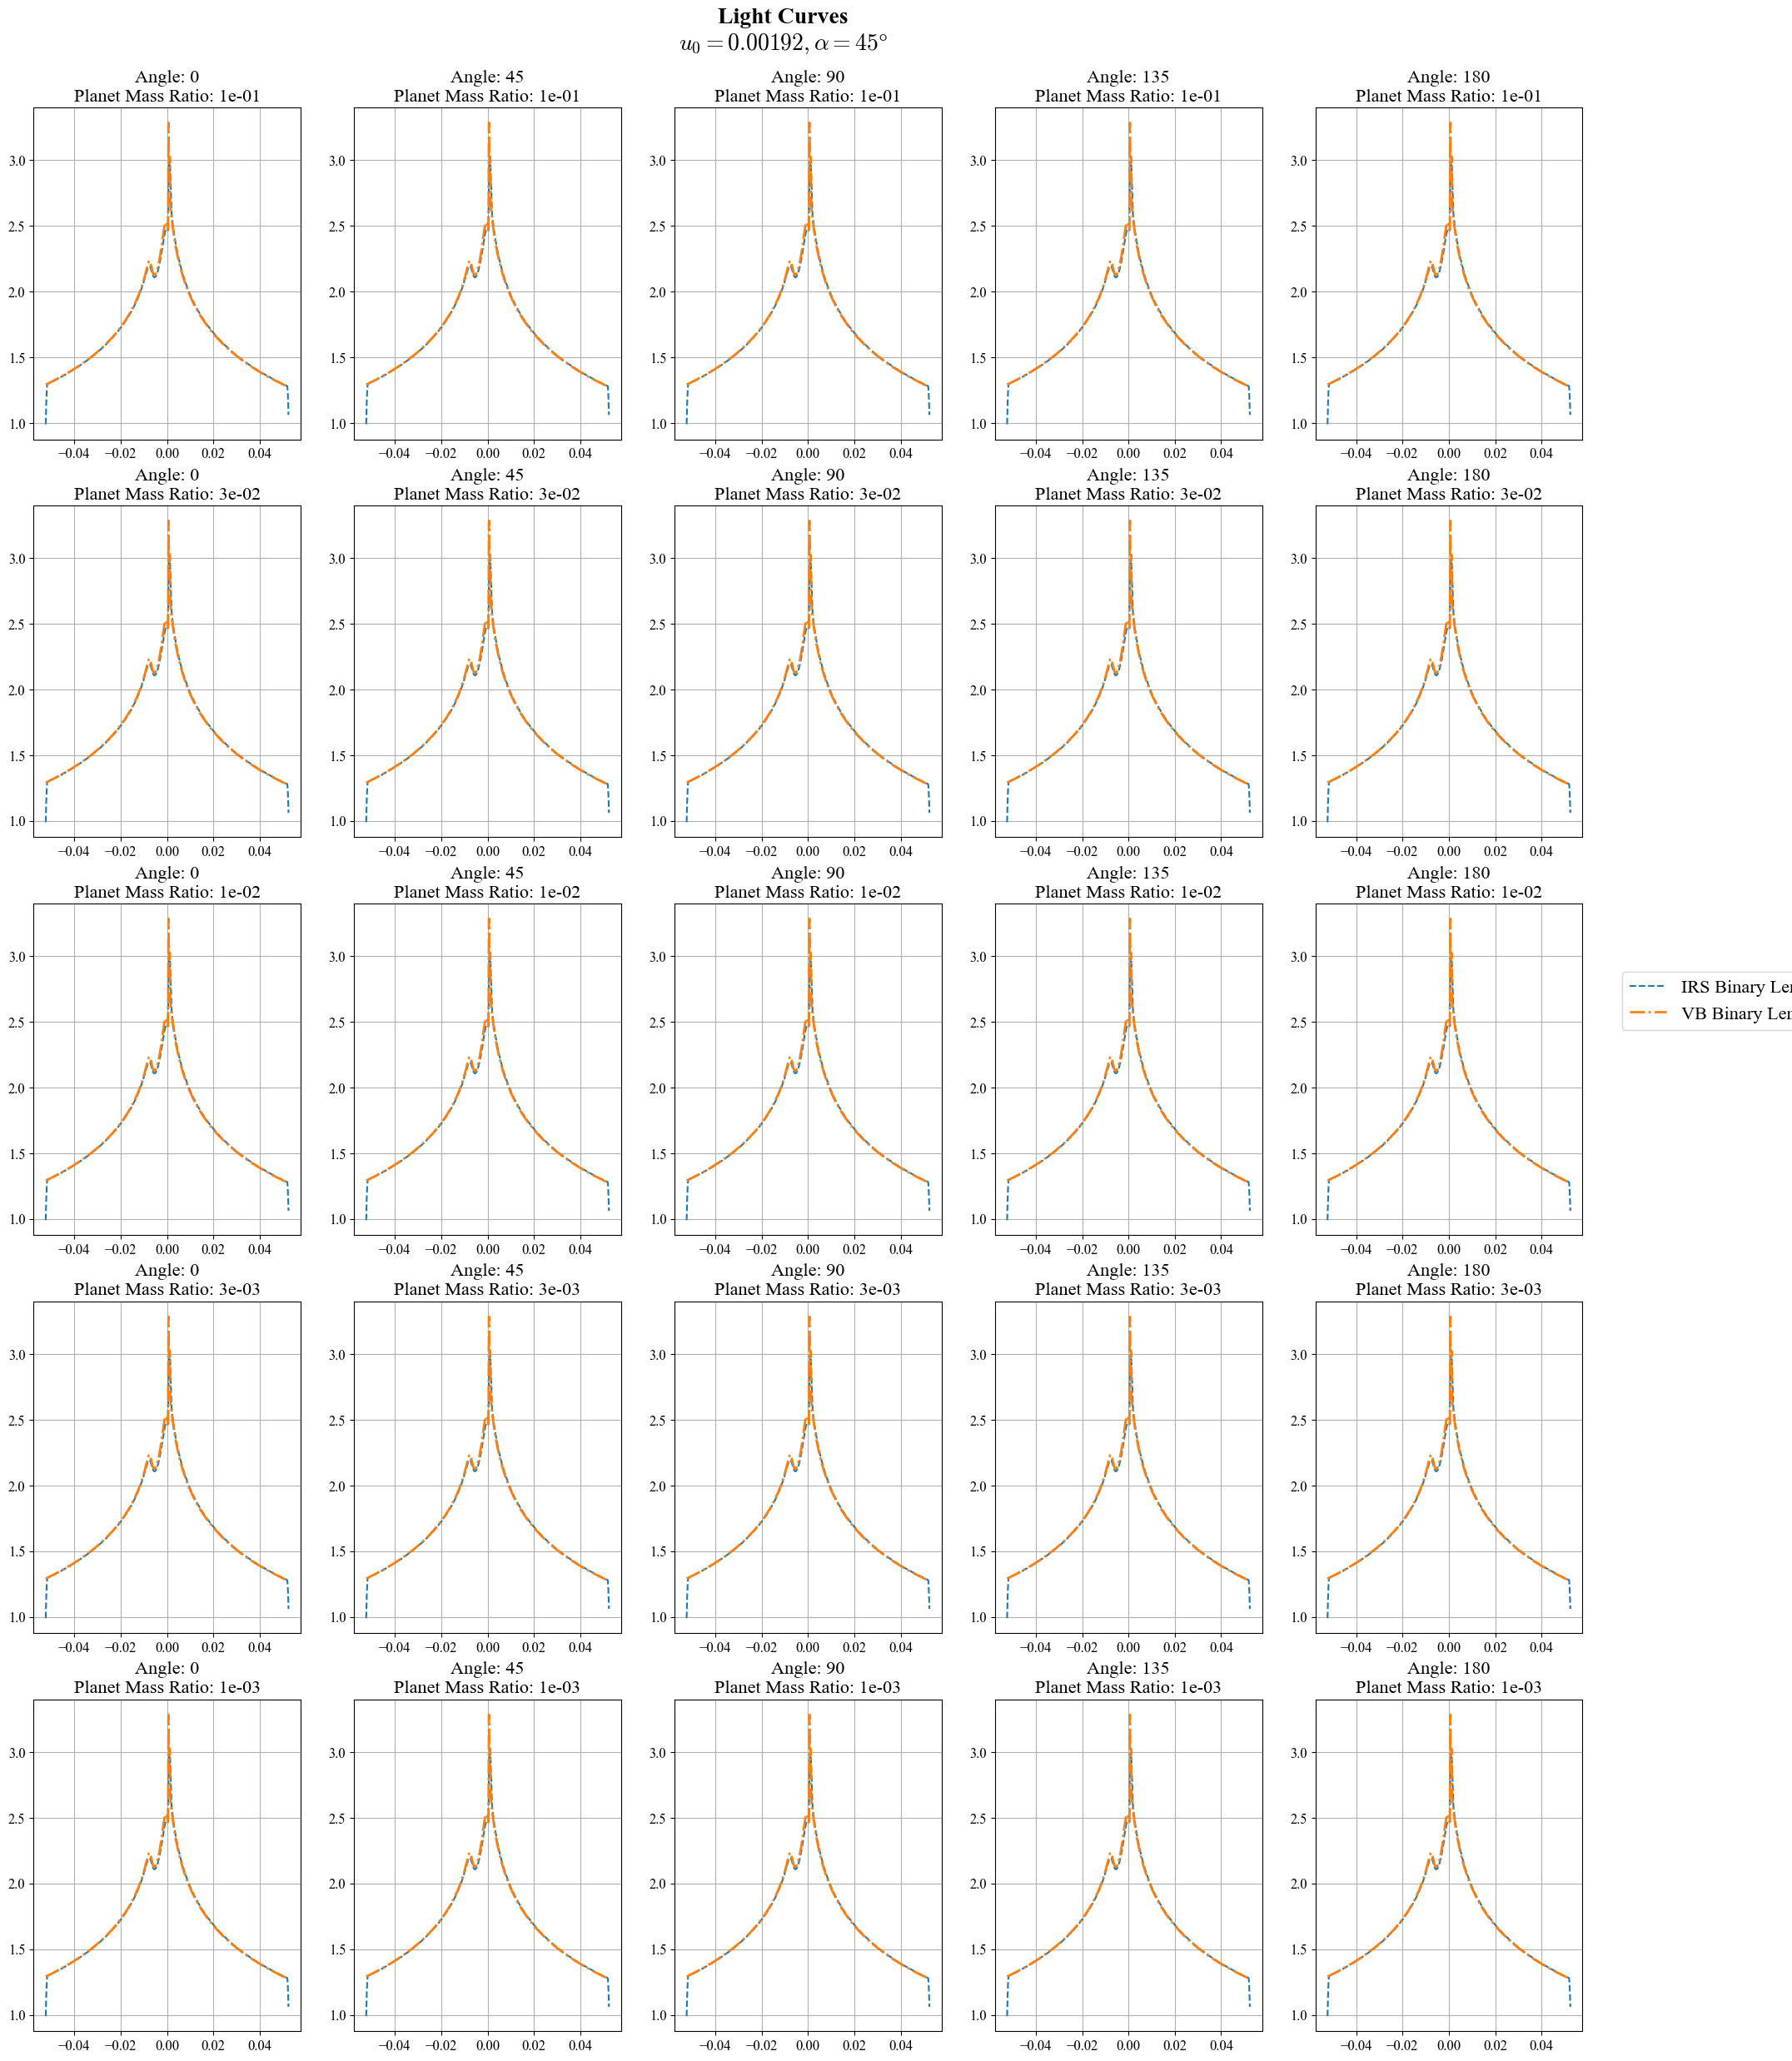

In [83]:
fig = plt.figure(figsize=(24, 30))
all_axes = fig.subplots(5, 5)
axes = all_axes

fig.suptitle(f'Light Curves\n$u_0 = {us[ind_u]:.5f}, \\alpha = {alphas[ind_alpha]:.0f}\degree$', y=0.92)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {betas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        one_configuration_brightness = brightness_distribution[i, j]
        one_configuration_brightness_binary_offset = brightness_distribution_binary_offset[i, j]
        one_configuration_brightness_cm_offset = brightness_distribution_cm_offset[i, j]
        binary_one_configuration_brightness = binary_brightness_distribution[i, j]

        one_configuration_times = time_distribution[i, j]

        if one_curve:
            brightness = one_configuration_brightness[ind_u, ind_alpha]
            brightness_binary_offset = one_configuration_brightness_binary_offset[ind_u, ind_alpha]
            brightness_cm_offset = one_configuration_brightness_cm_offset[ind_u, ind_alpha]
            binary_brightness = binary_one_configuration_brightness[ind_u, ind_alpha]
            
            times = one_configuration_times[ind_u, ind_alpha]

            # ax.plot(times, np.log10(brightness), label='Triple Offset')
            # ax.plot(times, np.log10(brightness_binary_offset), label='Binary Offset')
            # ax.plot(times, np.log10(brightness_cm_offset), label='CM Offset')
            ax.plot(times, np.log10(binary_brightness), label='IRS Binary Lens', linestyle='--')

            ax.plot(times, np.log10(VB_magnifications[ind_u][ind_alpha]), label='VB Binary Lens', linestyle='-.', linewidth=2)

        if not one_curve:
            for ind_u in range(len(us)):
                for ind_alpha in range(len(alphas)):
                    brightness = one_configuration_brightness[ind_u, ind_alpha]
                    times = one_configuration_times[ind_u, ind_alpha]

                    ax.plot(times, brightness, label=f'u = {us[ind_u]:.2f}, alpha = {alphas[ind_alpha]:.0f}')

        # for k, (brightness, times) in enumerate(zip(one_configuration_brightness, one_configuration_times)):
            
        #     # ax.plot(times, brightness, label=f'u = {us[k]:.2f}')

        # ax.set_xlabel('Time')
        # ax.set_ylabel('Brightness')
        ax.grid(True)
        # ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.905, 0.5), ncol=1, fontsize=16)

# fig.savefig('Light Curves Triple Lens.png', dpi=500)

plt.show()

1054.09800338509
940792.1272905949


[]

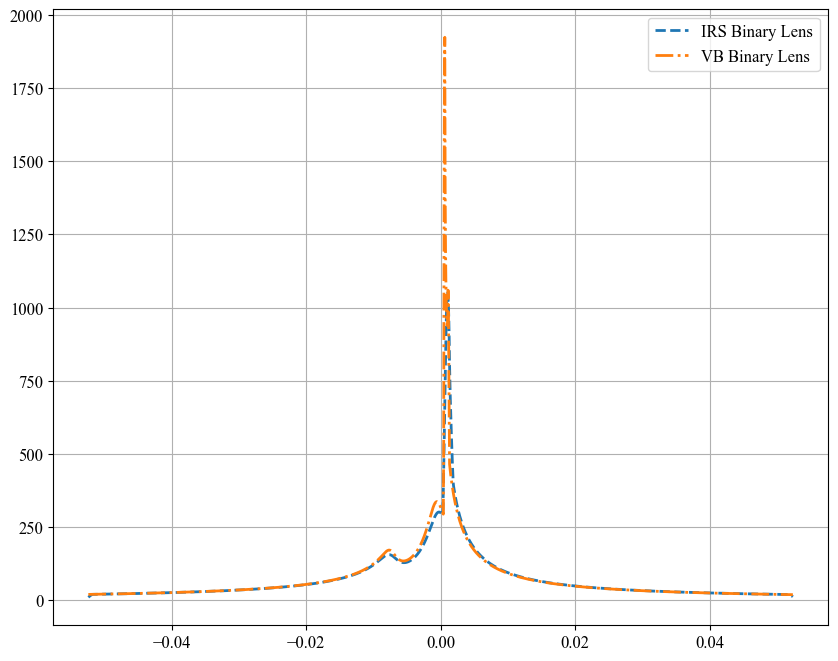

In [85]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.plot(times, (binary_brightness), label='IRS Binary Lens', linestyle='--', linewidth=2)

ax.plot(times, np.array(VB_magnifications[ind_u][ind_alpha]), label='VB Binary Lens', linestyle='-.', linewidth=2)

print(np.max(binary_brightness))
print(np.max(VB_magnifications[ind_u][ind_alpha]) * 489)

ax.legend()

ax.grid(True)

plt.plot()